# ⚛️🔧 NASA C-MAPSS: Klasik ML vs Kuantum ML — Kapsamlı Karşılaştırma
<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **FD001 · FD002 · FD003 · FD004 Desteği | 2024–2025 Literatür Karşılaştırması | Colab Uyumlu**

Bu notebook; NASA C-MAPSS veri setinin tüm alt kümelerinde (FD001–FD004) hem **Klasik ML** hem de **Kuantum ML (QML)** modellerini çalıştırarak kapsamlı bir karşılaştırma sunar.

## 📋 İçindekiler
| # | Bölüm | Kapsam |
|---|-------|--------|
| 0 | Kurulum & Bağımlılıklar | Colab-uyumlu kurulum |
| 1 | ⚙️ Yapılandırma Paneli | Veri seti / hiperparametre seçimi |
| 2 | 📦 Veri İndirme & Yükleme | FD001–FD004 otomatik |
| 3 | 🔍 Keşifsel Veri Analizi | EDA + sensör analizi |
| 4 | ⚙️ Özellik Mühendisliği | Normalizasyon, PCA, pencere |
| 5 | 🌲 Klasik ML | RF, SMOTE+RF, GBM, XGBoost, LSTM |
| 6 | ⚛️ Kuantum ML | VQC, QSVM, QLSTM, HQCNN |
| 7 | 📊 Model Karşılaştırması | Tüm modeller + görselleştirme |
| 8 | 📚 Literatür Karşılaştırması | 2024–2025 SOTA tablosu |
| 9 | 🗂️ Çok Veri Seti Taraması | FD001–FD004 toplu analiz |
| 10 | 🏁 Nihai Özet | Akademik çıkarımlar |

---
> ⚠️ **Colab GPU Notu:** `Çalışma Zamanı → Çalışma zamanı türünü değiştir → T4 GPU` seçin.  
> QML modelleri `default.qubit` simülatöründe çalışır. Gerçek QH için `qml.device("qiskit.ibmq", ...)` kullanın.

## 🔧 Bölüm 0: Kurulum & Bağımlılıklar

In [1]:
# ═══════════════════════════════════════════════════════════════════
# BAĞIMLILIK KURULUMU — İlk çalıştırmada ~3-5 dk sürebilir
# ═══════════════════════════════════════════════════════════════════
import subprocess, sys

packages = [
    "pennylane",
    "pennylane-lightning",
    "kagglehub",
    "imbalanced-learn",
    "xgboost",
    "tqdm",
]
for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"✓ {pkg}")
    except Exception as e:
        print(f"⚠️  {pkg} hatası: {e}")

print("\n✅ Tüm bağımlılıklar hazır!")

✓ pennylane
✓ pennylane-lightning
✓ kagglehub
✓ imbalanced-learn
✓ xgboost
✓ tqdm

✅ Tüm bağımlılıklar hazır!


In [2]:
# ═══════════════════════════════════════════════════════════════════
# IMPORTS
# ═══════════════════════════════════════════════════════════════════
import pennylane as qml
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
import xgboost as xgb

import time, warnings, os, urllib.request
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#7F77DD','#1D9E75','#EF9F27','#D85A30','#378ADD','#D4537E','#9B94E0','#6DC7A8']
CMAP_Q  = LinearSegmentedColormap.from_list("qml", ['#E6F1FB','#7F77DD','#26215C'])

print(f"⚛️  PennyLane : {qml.__version__}")
print(f"🔥 PyTorch   : {torch.__version__}")
print(f"⚡ XGBoost   : {xgb.__version__}")
print("✅ Kütüphaneler hazır!")

⚛️  PennyLane : 0.45.0
🔥 PyTorch   : 2.11.0+cu128
⚡ XGBoost   : 3.2.0
✅ Kütüphaneler hazır!


## ⚙️ Bölüm 1: Yapılandırma Paneli

> Aşağıdaki değişkenleri değiştirerek veri seti ve model parametrelerini ayarlayın.

| Subset | Koşul Sayısı | Arıza Modu | Zorluk |
|--------|-------------|------------|--------|
| FD001 | 1 | 1 | Kolay |
| FD002 | 6 | 1 | Orta |
| FD003 | 1 | 2 | Orta |
| FD004 | 6 | 2 | Zor |

In [3]:
# ═══════════════════════════════════════════════════════════════════
# 🎛️  YAPILANDIRMA PANELİ
# ═══════════════════════════════════════════════════════════════════

# ── Veri Seti ─────────────────────────────────────────────────────
SUBSET       = "FD002"   # ← DEĞİŞTİR: "FD001" / "FD002" / "FD003" / "FD004"

# ── Etiketleme ────────────────────────────────────────────────────
RUL_THRESH   = 30        # Arıza etiketi eşiği (çevrim)
MAX_RUL      = 125       # RUL kırpma

# ── Kuantum ───────────────────────────────────────────────────────
N_QUBITS     = 4         # Qubit sayısı (4–8; artırmak doğruluğu artırır, yavaşlatır)
N_LAYERS     = 3         # Devre derinliği
N_TRAIN_QML  = 2000      # QML eğitim örnekleri
N_TEST_QML   = 500       # QML test örnekleri
N_QSVM       = 600       # QSVM alt-örnekleme (O(n²) çekirdek)
QML_EPOCHS   = 15        # QML epoch (hız için 10, kalite için 30)

# ── Klasik ML ─────────────────────────────────────────────────────
SEEDS        = [42, 7, 13]         # 5 seed: [42, 7, 13, 99, 2024]
LSTM_WINDOW  = 15
LSTM_HIDDEN  = 64
LSTM_EPOCHS  = 30

# ── Genel ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"{'═'*45}")
print(f"  Seçili Veri Seti : {SUBSET}")
print(f"  Arıza Eşiği      : RUL ≤ {RUL_THRESH} çevrim")
print(f"  Qubit Sayısı     : {N_QUBITS}")
print(f"  QML Epoch        : {QML_EPOCHS}")
print(f"  Seed Sayısı      : {len(SEEDS)}")
print(f"{'═'*45}")

ALL_RESULTS  = {}   # Bu veri seti sonuçları
MULTI_RESULTS = {}  # Çok-veri seti sonuçları

═════════════════════════════════════════════
  Seçili Veri Seti : FD002
  Arıza Eşiği      : RUL ≤ 30 çevrim
  Qubit Sayısı     : 4
  QML Epoch        : 15
  Seed Sayısı      : 3
═════════════════════════════════════════════


## 📦 Bölüm 2: Veri İndirme & Yükleme

In [4]:
# ═══════════════════════════════════════════════════════════════════
# SÜTUN İSİMLERİ
# ═══════════════════════════════════════════════════════════════════
INDEX_COLS   = ['unit_number', 'time_cycles']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS  = [
    'T2','T24','T30','T50','P2','P15','P30',
    'Nf','Nc','epr','Ps30','phi','NRf','NRc',
    'BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32'
]
ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_COLS

def load_cmapss(base_path, subset='FD002'):
    train = pd.read_csv(f"{base_path}/train_{subset}.txt",
                        sep=r'\s+', header=None, names=ALL_COLS, engine='python')
    test  = pd.read_csv(f"{base_path}/test_{subset}.txt",
                        sep=r'\s+', header=None, names=ALL_COLS, engine='python')
    rul   = pd.read_csv(f"{base_path}/RUL_{subset}.txt",
                        sep=r'\s+', header=None, names=['RUL'], engine='python')
    return train, test, rul

BASE_PATH = None

# Strateji 1: kagglehub
try:
    import kagglehub
    print("⏳ Kaggle'dan indiriliyor...")
    path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
    for subdir in ['CMaps', '', 'data']:
        candidate = os.path.join(path, subdir)
        if os.path.exists(os.path.join(candidate, f"train_{SUBSET}.txt")):
            BASE_PATH = candidate
            break
    if BASE_PATH is None:
        for root, dirs, files in os.walk(path):
            if f"train_{SUBSET}.txt" in files:
                BASE_PATH = root
                break
    print(f"✅ Kagglehub → {BASE_PATH}")
except Exception as e:
    print(f"⚠️  Kagglehub başarısız: {e}")

# Strateji 2: GitHub raw
if BASE_PATH is None:
    print("⏳ GitHub'dan indiriliyor...")
    DATA_DIR = "/tmp/cmapss"
    os.makedirs(DATA_DIR, exist_ok=True)
    BASE_RAW = "https://raw.githubusercontent.com/bagustris/NASA-turbofan-jet-engine-data-set/main/CMaps"
    for sub in ["FD001","FD002","FD003","FD004"]:
        for prefix in ["train_","test_","RUL_"]:
            fname = f"{prefix}{sub}.txt"
            dest  = f"{DATA_DIR}/{fname}"
            if not os.path.exists(dest):
                try:
                    urllib.request.urlretrieve(f"{BASE_RAW}/{fname}", dest)
                    print(f"  ✓ {fname}")
                except Exception as ex:
                    print(f"  ✗ {fname}: {ex}")
    BASE_PATH = DATA_DIR

train_raw, test_raw, rul_raw = load_cmapss(BASE_PATH, SUBSET)
print(f"\n📊 {SUBSET} yüklendi:")
print(f"   Eğitim : {train_raw.shape}  |  Test : {test_raw.shape}")
print(f"   Eğitim Motor Sayısı : {train_raw['unit_number'].nunique()}")
print(f"   Test   Motor Sayısı : {test_raw['unit_number'].nunique()}")

⏳ Kaggle'dan indiriliyor...
Using Colab cache for faster access to the 'nasa-cmaps' dataset.
✅ Kagglehub → /kaggle/input/nasa-cmaps/CMaps

📊 FD002 yüklendi:
   Eğitim : (53759, 26)  |  Test : (33991, 26)
   Eğitim Motor Sayısı : 260
   Test   Motor Sayısı : 259


## 🔍 Bölüm 3: Keşifsel Veri Analizi (EDA)

In [5]:
# ─── RUL Hesaplama ────────────────────────────────────────────────
def compute_rul(df, max_rul=125):
    max_cycle = df.groupby('unit_number')['time_cycles'].max().reset_index()
    max_cycle.columns = ['unit_number', 'max_cycle']
    df = df.merge(max_cycle, on='unit_number', how='left')
    df['RUL'] = (df['max_cycle'] - df['time_cycles']).clip(upper=max_rul)
    df.drop('max_cycle', axis=1, inplace=True)
    return df

train_df = compute_rul(train_raw.copy(), MAX_RUL)
train_df['label'] = (train_df['RUL'] <= RUL_THRESH).astype(int)

# Test: son kayıt + gerçek RUL
test_last = test_raw.groupby('unit_number').last().reset_index()
test_last['RUL']   = rul_raw['RUL'].values[:len(test_last)]
test_last['label'] = (test_last['RUL'] <= RUL_THRESH).astype(int)

label_cnt = train_df['label'].value_counts()
lifetimes = train_df.groupby('unit_number')['time_cycles'].max()

print("═" * 55)
print(f"  NASA C-MAPSS {SUBSET} — Özet")
print("═" * 55)
print(f"  Motor (eğitim) : {train_df['unit_number'].nunique()}")
print(f"  Motor (test)   : {test_raw['unit_number'].nunique()}")
print(f"  Kayıt (eğitim) : {len(train_df):,}")
print(f"  Arızalı        : {label_cnt.get(1,0):,}  ({label_cnt.get(1,0)/len(train_df)*100:.1f}%)")
print(f"  Sağlam         : {label_cnt.get(0,0):,}  ({label_cnt.get(0,0)/len(train_df)*100:.1f}%)")
print(f"  Ort. Motor Ömrü: {lifetimes.mean():.1f}  |  Min/Max: {lifetimes.min()}/{lifetimes.max()}")
print("═" * 55)

═══════════════════════════════════════════════════════
  NASA C-MAPSS FD002 — Özet
═══════════════════════════════════════════════════════
  Motor (eğitim) : 260
  Motor (test)   : 259
  Kayıt (eğitim) : 53,759
  Arızalı        : 8,060  (15.0%)
  Sağlam         : 45,699  (85.0%)
  Ort. Motor Ömrü: 206.8  |  Min/Max: 128/378
═══════════════════════════════════════════════════════


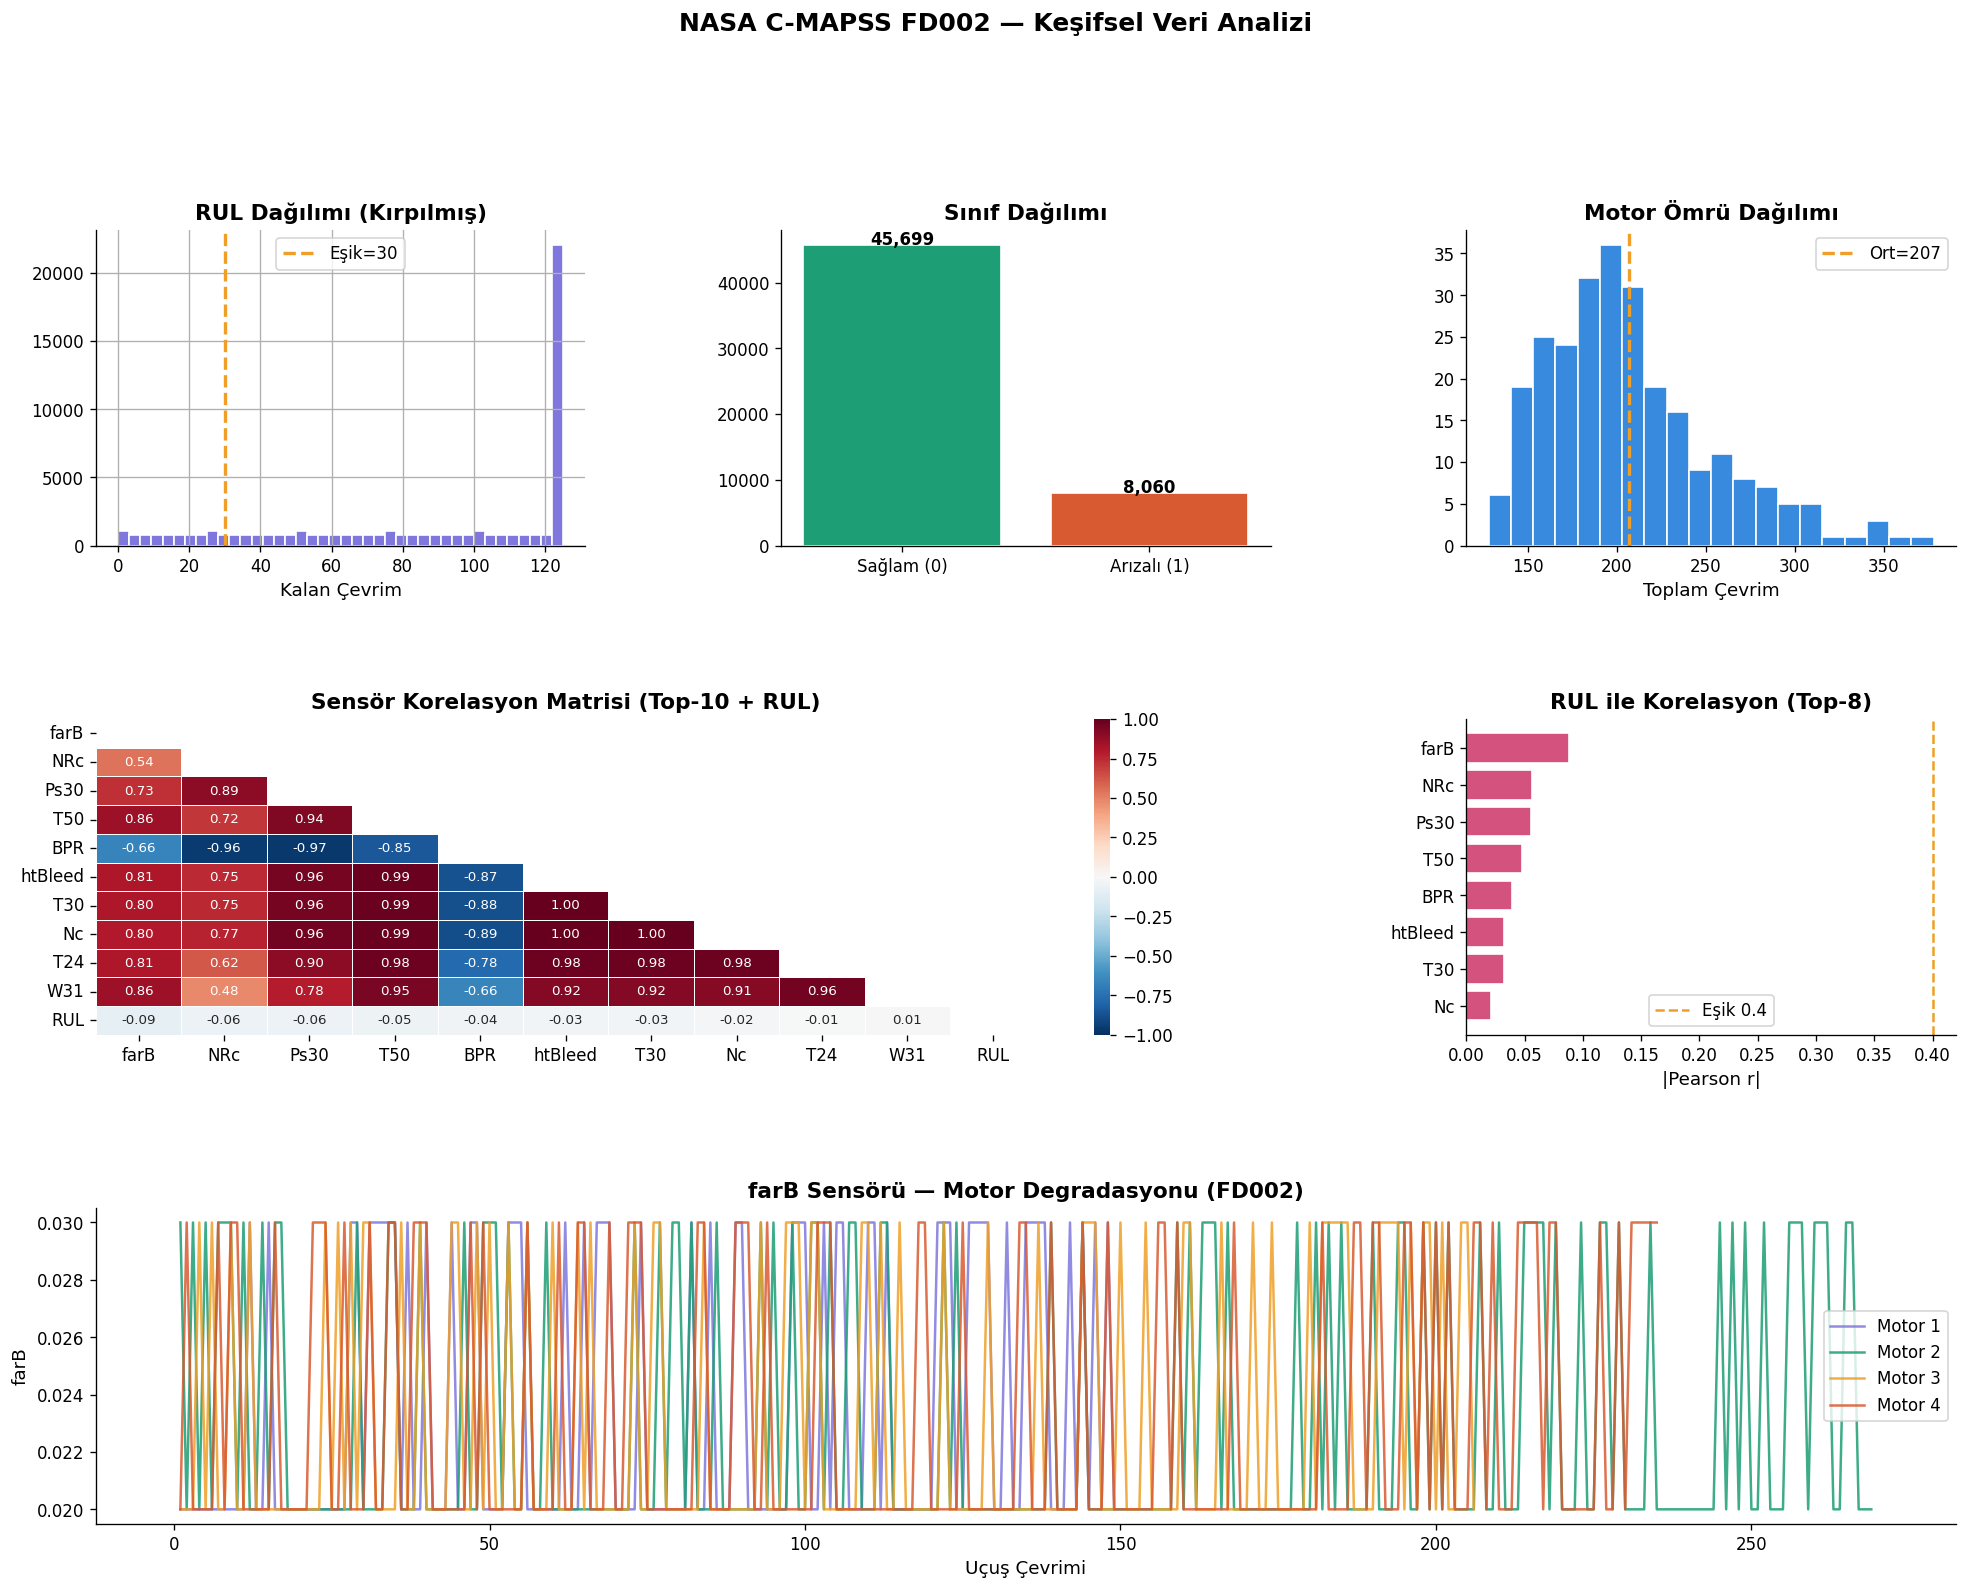

✅ EDA tamamlandı → eda_FD002.png


In [6]:
# ─── EDA Görselleştirmeler ────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# 1. RUL Dağılımı
ax1 = fig.add_subplot(gs[0, 0])
train_df['RUL'].hist(bins=40, ax=ax1, color=PALETTE[0], edgecolor='white')
ax1.axvline(RUL_THRESH, color=PALETTE[2], lw=2, ls='--', label=f'Eşik={RUL_THRESH}')
ax1.set_title('RUL Dağılımı (Kırpılmış)', fontweight='bold')
ax1.set_xlabel('Kalan Çevrim'); ax1.legend()

# 2. Sınıf Dengesi
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(['Sağlam (0)', 'Arızalı (1)'], label_cnt.values,
               color=[PALETTE[1], PALETTE[3]], edgecolor='white')
for b, v in zip(bars, label_cnt.values):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+50, f'{v:,}',
             ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Sınıf Dağılımı', fontweight='bold')

# 3. Motor Ömrü
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(lifetimes, bins=20, color=PALETTE[4], edgecolor='white')
ax3.axvline(lifetimes.mean(), color=PALETTE[2], lw=2, ls='--',
            label=f'Ort={lifetimes.mean():.0f}')
ax3.set_title('Motor Ömrü Dağılımı', fontweight='bold')
ax3.set_xlabel('Toplam Çevrim'); ax3.legend()

# 4. Korelasyon Isı Haritası
ax4 = fig.add_subplot(gs[1, :2])
corr_df   = train_df[SENSOR_COLS + ['RUL']].corr()
top_s     = corr_df['RUL'].drop('RUL').abs().sort_values(ascending=False).head(10).index.tolist()
corr_sub  = train_df[top_s + ['RUL']].corr()
mask      = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax4, annot_kws={'size': 8})
ax4.set_title('Sensör Korelasyon Matrisi (Top-10 + RUL)', fontweight='bold')

# 5. RUL ile Korelasyon
ax5 = fig.add_subplot(gs[1, 2])
corrs   = train_df[SENSOR_COLS + ['RUL']].corr()['RUL'].drop('RUL').abs().sort_values()
top8    = corrs.tail(8)
cb      = [PALETTE[0] if v > 0.4 else PALETTE[5] for v in top8.values]
ax5.barh(top8.index, top8.values, color=cb, edgecolor='white')
ax5.axvline(0.4, color=PALETTE[2], ls='--', lw=1.5, label='Eşik 0.4')
ax5.set_title('RUL ile Korelasyon (Top-8)', fontweight='bold')
ax5.set_xlabel('|Pearson r|'); ax5.legend()

# 6. Sensör Degradasyonu
ax6 = fig.add_subplot(gs[2, :])
top_sensor = corrs.idxmax()
for uid, c in zip(train_df['unit_number'].unique()[:4], PALETTE[:4]):
    sub = train_df[train_df['unit_number'] == uid]
    ax6.plot(sub['time_cycles'], sub[top_sensor], color=c, alpha=0.85,
             lw=1.5, label=f'Motor {uid}')
ax6.set_title(f'{top_sensor} Sensörü — Motor Degradasyonu ({SUBSET})', fontweight='bold')
ax6.set_xlabel('Uçuş Çevrimi'); ax6.set_ylabel(top_sensor); ax6.legend()

plt.suptitle(f'NASA C-MAPSS {SUBSET} — Keşifsel Veri Analizi',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig(f'eda_{SUBSET}.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ EDA tamamlandı → eda_{SUBSET}.png")

## ⚙️ Bölüm 4: Özellik Mühendisliği & Ön-İşleme

In [7]:
# ═══════════════════════════════════════════════════════════════════
# ÖZELLİK MÜHENDİSLİĞİ
# ═══════════════════════════════════════════════════════════════════

# Sabit sensörleri çıkar
constant_sensors = [c for c in SENSOR_COLS if train_df[c].std() < 0.01]
active_sensors   = [c for c in SENSOR_COLS if c not in constant_sensors]
FEATURE_COLS     = active_sensors + [s for s in SETTING_COLS if train_df[s].std() > 0.01]
print(f"Sabit sensörler ({len(constant_sensors)}): {constant_sensors}")
print(f"Aktif özellik sayısı: {len(FEATURE_COLS)}")

X_raw      = train_df[FEATURE_COLS].values
y_raw      = train_df['label'].values
X_test_raw = test_last[FEATURE_COLS].values
y_test_raw = test_last['label'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_test_s = scaler.transform(X_test_raw)

print(f"\nEğitim : {X_scaled.shape}  |  Test : {X_test_s.shape}")
print(f"Arıza oranı — Eğitim: {y_raw.mean()*100:.1f}%  |  Test: {y_test_raw.mean()*100:.1f}%")

# ─── QML için PCA + AngleEmbedding ───────────────────────────────
pca      = PCA(n_components=N_QUBITS, random_state=SEED)
X_pca    = pca.fit_transform(X_scaled)
X_tp     = pca.transform(X_test_s)
print(f"\nPCA açıklanan varyans: {pca.explained_variance_ratio_.sum()*100:.1f}%  ({N_QUBITS} bileşen)")

def to_angle(X):
    mn, mx = X.min(0), X.max(0)
    return np.pi * (2 * (X - mn) / (mx - mn + 1e-8) - 1)

X_norm      = to_angle(X_pca)
X_test_norm = to_angle(X_tp)

rng     = np.random.RandomState(SEED)
tr_idx  = rng.choice(len(X_scaled), min(N_TRAIN_QML, len(X_scaled)), replace=False)
te_idx  = rng.choice(len(X_test_s), min(N_TEST_QML,  len(X_test_s)),  replace=False)

X_qml_tr, y_qml_tr = X_norm[tr_idx],      y_raw[tr_idx]
X_qml_te, y_qml_te = X_test_norm[te_idx], y_test_raw[te_idx]

q_tr = rng.choice(len(X_qml_tr), min(N_QSVM, len(X_qml_tr)), replace=False)
q_te = rng.choice(len(X_qml_te), min(200,   len(X_qml_te)),  replace=False)
X_qsvm_tr, y_qsvm_tr = X_qml_tr[q_tr], y_qml_tr[q_tr]
X_qsvm_te, y_qsvm_te = X_qml_te[q_te], y_qml_te[q_te]

print(f"\nQML Eğitim : {X_qml_tr.shape}  |  QSVM : {X_qsvm_tr.shape}")
print("✅ Ön-işleme tamamlandı!")

# ─── Yardımcı fonksiyonlar ────────────────────────────────────────
def evaluate(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs > threshold).astype(int)
    auc = roc_auc_score(y_true, y_probs) if len(np.unique(y_true)) > 1 else 0.5
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'F1-Score' : f1_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'AUC-ROC'  : auc,
        'y_pred'   : y_pred,
        'y_probs'  : y_probs,
    }

def youden_threshold(y_val, probs):
    fpr, tpr, thr = roc_curve(y_val, probs)
    idx = np.argmax(tpr - fpr)
    return thr[idx]

METRICS = ['Accuracy','F1-Score','Precision','Recall','AUC-ROC']

Sabit sensörler (1): ['farB']
Aktif özellik sayısı: 23

Eğitim : (53759, 23)  |  Test : (259, 23)
Arıza oranı — Eğitim: 15.0%  |  Test: 23.6%

PCA açıklanan varyans: 99.8%  (4 bileşen)

QML Eğitim : (2000, 4)  |  QSVM : (600, 4)
✅ Ön-işleme tamamlandı!


## 🌲 Bölüm 5: Klasik ML Modeller

In [8]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 5.1 — Random Forest (Balanced + Youden-J)
# ═══════════════════════════════════════════════════════════════════
print("🌲 Random Forest eğitiliyor..."); t0 = time.time()
rf_results = []
for seed in SEEDS:
    Xtr, Xvl, ytr, yvl = train_test_split(X_scaled, y_raw, test_size=0.2,
                                            random_state=seed, stratify=y_raw)
    rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                 random_state=seed, n_jobs=-1)
    rf.fit(Xtr, ytr)
    thr   = youden_threshold(yvl, rf.predict_proba(Xvl)[:,1])
    probs = rf.predict_proba(X_test_s)[:,1]
    res   = evaluate(y_test_raw, probs, thr)
    res.update({'seed':seed,'model':rf,'threshold':thr})
    rf_results.append(res)
    print(f"  Seed {seed} | F1={res['F1-Score']:.4f} | AUC={res['AUC-ROC']:.4f}")

rf_df = pd.DataFrame(rf_results)
ALL_RESULTS['RF (Balanced)'] = {m: rf_df[m].mean() for m in METRICS}
ALL_RESULTS['RF (Balanced)']['std_F1'] = rf_df['F1-Score'].std()
best_rf = rf_results[rf_df['F1-Score'].idxmax()]
print(f"  ✅ RF | F1={rf_df['F1-Score'].mean():.4f}±{rf_df['F1-Score'].std():.4f} | {time.time()-t0:.0f}s")

🌲 Random Forest eğitiliyor...
  Seed 42 | F1=0.8429 | AUC=0.9897
  Seed 7 | F1=0.8676 | AUC=0.9840
  Seed 13 | F1=0.8429 | AUC=0.9915
  ✅ RF | F1=0.8511±0.0143 | 57s


In [9]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 5.2 — SMOTE + Random Forest
# ═══════════════════════════════════════════════════════════════════
print("🌿 SMOTE + RF eğitiliyor..."); t0 = time.time()
smote_results = []
for seed in SEEDS:
    Xtr, Xvl, ytr, yvl = train_test_split(X_scaled, y_raw, test_size=0.2,
                                            random_state=seed, stratify=y_raw)
    Xsm, ysm = SMOTE(random_state=seed).fit_resample(Xtr, ytr)
    rfs = RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1)
    rfs.fit(Xsm, ysm)
    thr   = youden_threshold(yvl, rfs.predict_proba(Xvl)[:,1])
    probs = rfs.predict_proba(X_test_s)[:,1]
    res   = evaluate(y_test_raw, probs, thr)
    res.update({'seed':seed})
    smote_results.append(res)
    print(f"  Seed {seed} | F1={res['F1-Score']:.4f} | AUC={res['AUC-ROC']:.4f}")

smote_df = pd.DataFrame(smote_results)
ALL_RESULTS['SMOTE + RF'] = {m: smote_df[m].mean() for m in METRICS}
ALL_RESULTS['SMOTE + RF']['std_F1'] = smote_df['F1-Score'].std()
print(f"  ✅ SMOTE+RF | F1={smote_df['F1-Score'].mean():.4f}±{smote_df['F1-Score'].std():.4f} | {time.time()-t0:.0f}s")

🌿 SMOTE + RF eğitiliyor...
  Seed 42 | F1=0.8310 | AUC=0.9899
  Seed 7 | F1=0.8082 | AUC=0.9904
  Seed 13 | F1=0.8613 | AUC=0.9890
  ✅ SMOTE+RF | F1=0.8335±0.0266 | 138s


In [10]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 5.3 — Gradient Boosting (GBM)
# ═══════════════════════════════════════════════════════════════════
print("🚀 GBM eğitiliyor..."); t0 = time.time()
gbm_results = []
for seed in SEEDS:
    Xtr, Xvl, ytr, yvl = train_test_split(X_scaled, y_raw, test_size=0.2,
                                            random_state=seed, stratify=y_raw)
    sw  = compute_sample_weight('balanced', ytr)
    gbm = GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                      learning_rate=0.1, random_state=seed)
    gbm.fit(Xtr, ytr, sample_weight=sw)
    thr   = youden_threshold(yvl, gbm.predict_proba(Xvl)[:,1])
    probs = gbm.predict_proba(X_test_s)[:,1]
    res   = evaluate(y_test_raw, probs, thr)
    res.update({'seed':seed})
    gbm_results.append(res)
    print(f"  Seed {seed} | F1={res['F1-Score']:.4f} | AUC={res['AUC-ROC']:.4f}")

gbm_df = pd.DataFrame(gbm_results)
ALL_RESULTS['GBM'] = {m: gbm_df[m].mean() for m in METRICS}
ALL_RESULTS['GBM']['std_F1'] = gbm_df['F1-Score'].std()
print(f"  ✅ GBM | F1={gbm_df['F1-Score'].mean():.4f}±{gbm_df['F1-Score'].std():.4f} | {time.time()-t0:.0f}s")

🚀 GBM eğitiliyor...
  Seed 42 | F1=0.8392 | AUC=0.9925
  Seed 7 | F1=0.8392 | AUC=0.9932
  Seed 13 | F1=0.8511 | AUC=0.9928
  ✅ GBM | F1=0.8431±0.0069 | 111s


In [11]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 5.4 — XGBoost
# ═══════════════════════════════════════════════════════════════════
print("⚡ XGBoost eğitiliyor..."); t0 = time.time()
scale_pos = int((y_raw == 0).sum() / max((y_raw == 1).sum(), 1))
xgb_results = []
for seed in SEEDS:
    Xtr, Xvl, ytr, yvl = train_test_split(X_scaled, y_raw, test_size=0.2,
                                            random_state=seed, stratify=y_raw)
    clf = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              scale_pos_weight=scale_pos, random_state=seed,
                              eval_metric='logloss', verbosity=0, use_label_encoder=False)
    clf.fit(Xtr, ytr, eval_set=[(Xvl, yvl)], verbose=False)
    thr   = youden_threshold(yvl, clf.predict_proba(Xvl)[:,1])
    probs = clf.predict_proba(X_test_s)[:,1]
    res   = evaluate(y_test_raw, probs, thr)
    res.update({'seed':seed,'model':clf,'threshold':thr})
    xgb_results.append(res)
    print(f"  Seed {seed} | F1={res['F1-Score']:.4f} | AUC={res['AUC-ROC']:.4f}")

xgb_df = pd.DataFrame(xgb_results)
ALL_RESULTS['XGBoost'] = {m: xgb_df[m].mean() for m in METRICS}
ALL_RESULTS['XGBoost']['std_F1'] = xgb_df['F1-Score'].std()
best_xgb = xgb_results[xgb_df['F1-Score'].idxmax()]
print(f"  ✅ XGBoost | F1={xgb_df['F1-Score'].mean():.4f}±{xgb_df['F1-Score'].std():.4f} | {time.time()-t0:.0f}s")

⚡ XGBoost eğitiliyor...
  Seed 42 | F1=0.8429 | AUC=0.9924
  Seed 7 | F1=0.8451 | AUC=0.9938
  Seed 13 | F1=0.8429 | AUC=0.9924
  ✅ XGBoost | F1=0.8436±0.0013 | 5s


In [12]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 5.5 — Klasik LSTM (QML referans noktası)
# ═══════════════════════════════════════════════════════════════════
print("🧠 LSTM eğitiliyor...")

def make_windows(X, y, window=15):
    Xw, yw = [], []
    for i in range(len(X) - window + 1):
        Xw.append(X[i:i+window])
        yw.append(y[i+window-1])
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.float32)

Xw, yw = make_windows(X_scaled, y_raw, LSTM_WINDOW)
print(f"  Pencereli dizi: {Xw.shape}  |  Arıza: {yw.mean()*100:.1f}%")

class LSTMClassifier(nn.Module):
    def __init__(self, inp, hid=64, layers=2, drop=0.2):
        super().__init__()
        self.lstm = nn.LSTM(inp, hid, layers, batch_first=True, dropout=drop)
        self.fc   = nn.Sequential(nn.Linear(hid,32), nn.ReLU(),
                                   nn.Dropout(0.2), nn.Linear(32,1), nn.Sigmoid())
    def forward(self, x):
        out, _ = self.lstm(x); return self.fc(out[:,-1,:])

lstm_results = []
N_FEAT = X_scaled.shape[1]

for seed in SEEDS:
    torch.manual_seed(seed); np.random.seed(seed)
    Xwt, Xwv, ywt, ywv = train_test_split(Xw, yw, test_size=0.2,
                                            random_state=seed, stratify=yw)
    pw   = torch.tensor([(ywt==0).sum()/max((ywt==1).sum(),1)])
    m    = LSTMClassifier(N_FEAT, LSTM_HIDDEN)
    opt  = optim.Adam(m.parameters(), lr=0.001)
    bce  = nn.BCELoss()
    ldr  = DataLoader(TensorDataset(torch.tensor(Xwt), torch.tensor(ywt).unsqueeze(1)),
                      batch_size=64, shuffle=True)
    for _ in range(LSTM_EPOCHS):
        m.train()
        for xb, yb in ldr:
            opt.zero_grad()
            pred = m(xb).view_as(yb)
            w    = torch.where(yb==1, pw, torch.ones(1))
            (bce(pred, yb)*w).mean().backward()
            opt.step()
    m.eval()
    with torch.no_grad():
        pr = m(torch.tensor(Xwv)).squeeze().numpy()
    thr = youden_threshold(ywv, pr)
    res = evaluate(ywv, pr, thr); res['seed'] = seed
    lstm_results.append(res)
    print(f"  Seed {seed} | F1={res['F1-Score']:.4f} | AUC={res['AUC-ROC']:.4f}")

lstm_df = pd.DataFrame(lstm_results)
ALL_RESULTS['Klasik LSTM'] = {m: lstm_df[m].mean() for m in METRICS}
ALL_RESULTS['Klasik LSTM']['std_F1'] = lstm_df['F1-Score'].std()
print(f"  ✅ LSTM | F1={lstm_df['F1-Score'].mean():.4f}±{lstm_df['F1-Score'].std():.4f}")

🧠 LSTM eğitiliyor...
  Pencereli dizi: (53745, 15, 23)  |  Arıza: 15.0%
  Seed 42 | F1=0.9605 | AUC=0.9990
  Seed 7 | F1=0.9520 | AUC=0.9991
  Seed 13 | F1=0.9305 | AUC=0.9972
  ✅ LSTM | F1=0.9477±0.0154


## ⚛️ Bölüm 6: Kuantum ML Modeller

> Tüm modeller `default.qubit` PennyLane simülatöründe çalışır.  
> Referanslar: Cerezo et al. 2021 (VQC) · Havlíček et al. 2019 (QSVM) · Tsurkan et al. 2025 (QLSTM) · Sudharson et al. 2025 (HQCNN)

In [13]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 6.1 — VQC (Variational Quantum Classifier)
# Ref: Cerezo et al., Nat. Rev. Phys. 3, 625–644 (2021)
# ═══════════════════════════════════════════════════════════════════
print("⚛️  VQC eğitiliyor..."); t0 = time.time()

dev_vqc = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_vqc, interface="torch")
def vqc_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return qml.expval(qml.PauliZ(0))

class VQCModel(nn.Module):
    def __init__(self):
        super().__init__()
        ws = qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS)
        self.weights = nn.Parameter(torch.randn(*ws) * 0.1)
        self.bias    = nn.Parameter(torch.zeros(1))
    def forward(self, x):
        out = torch.stack([vqc_circuit(xi, self.weights) for xi in x])
        out = out.float()  # ← bunu ekle
        return torch.sigmoid(out + self.bias)

vqc_model = VQCModel()
vqc_opt   = optim.Adam(vqc_model.parameters(), lr=0.05)
vqc_bce   = nn.BCELoss()
Xvt = torch.tensor(X_qml_tr, dtype=torch.float32)
yvt = torch.tensor(y_qml_tr, dtype=torch.float32)
Xve = torch.tensor(X_qml_te, dtype=torch.float32)

pos_w_qml = torch.tensor([(y_qml_tr==0).sum()/max((y_qml_tr==1).sum(),1)])

for ep in range(QML_EPOCHS):
    vqc_model.train()
    perm = torch.randperm(len(Xvt))
    for i in range(0, len(perm), 32):
        idx = perm[i:i+32]
        xb, yb = Xvt[idx], yvt[idx]
        vqc_opt.zero_grad()
        pred = vqc_model(xb).squeeze()
        w    = torch.where(yb==1, pos_w_qml, torch.ones(1))
        loss = (vqc_bce(pred, yb) * w).mean()
        loss.backward(); vqc_opt.step()
    if (ep+1) % 5 == 0:
        print(f"  Epoch [{ep+1}/{QML_EPOCHS}] | Loss={loss.item():.4f} | {time.time()-t0:.0f}s")

vqc_model.eval()
with torch.no_grad():
    vqc_pr = vqc_model(Xve).squeeze().numpy()
vqc_thr = youden_threshold(y_qml_te, vqc_pr)
vqc_res = evaluate(y_qml_te, vqc_pr, vqc_thr)
ALL_RESULTS['VQC'] = {m: vqc_res[m] for m in METRICS}; ALL_RESULTS['VQC']['std_F1']=0.0
print(f"  ✅ VQC | F1={vqc_res['F1-Score']:.4f} | AUC={vqc_res['AUC-ROC']:.4f} | {time.time()-t0:.0f}s")

⚛️  VQC eğitiliyor...
  Epoch [5/15] | Loss=0.9576 | 234s
  Epoch [10/15] | Loss=0.5541 | 467s
  Epoch [15/15] | Loss=0.7128 | 697s
  ✅ VQC | F1=0.6400 | AUC=0.7916 | 699s


In [14]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 6.2 — QSVM (Quantum Kernel SVM)
# Ref: Havlíček et al., Nature 567, 209–212 (2019)
# ═══════════════════════════════════════════════════════════════════
print("⚛️  QSVM çekirdeği hesaplanıyor..."); t0 = time.time()
print(f"  Eğitim: {X_qsvm_tr.shape}  |  Test: {X_qsvm_te.shape}")

dev_qs = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_qs)
def kernel_circuit(x1, x2):
    qml.AngleEmbedding(x1, wires=range(N_QUBITS), rotation='Y')
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(N_QUBITS), rotation='Y')
    return qml.probs(wires=range(N_QUBITS))

def quantum_kernel(X1, X2):
    K = np.zeros((len(X1), len(X2)))
    for i in range(len(X1)):
        for j in range(len(X2)):
            K[i,j] = kernel_circuit(X1[i], X2[j])[0]
    return K

K_tr = quantum_kernel(X_qsvm_tr, X_qsvm_tr)
K_te = quantum_kernel(X_qsvm_te, X_qsvm_tr)
print(f"  Çekirdek matrisi → {time.time()-t0:.0f}s")

qsvm = SVC(kernel='precomputed', class_weight='balanced', probability=True)
qsvm.fit(K_tr, y_qsvm_tr)
qsvm_pr  = qsvm.predict_proba(K_te)[:,1]
qsvm_thr = youden_threshold(y_qsvm_te, qsvm_pr)
qsvm_res = evaluate(y_qsvm_te, qsvm_pr, qsvm_thr)
ALL_RESULTS['QSVM'] = {m: qsvm_res[m] for m in METRICS}; ALL_RESULTS['QSVM']['std_F1']=0.0
print(f"  ✅ QSVM | F1={qsvm_res['F1-Score']:.4f} | AUC={qsvm_res['AUC-ROC']:.4f}")

⚛️  QSVM çekirdeği hesaplanıyor...
  Eğitim: (600, 4)  |  Test: (200, 4)
  Çekirdek matrisi → 941s
  ✅ QSVM | F1=0.6765 | AUC=0.9172


In [15]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 6.3 — QLSTM (Hybrid Quantum LSTM)
# Ref: Tsurkan et al., arXiv:2504.20823, Terra Quantum AG (2025)
# ═══════════════════════════════════════════════════════════════════
print("⚛️  QLSTM eğitiliyor..."); t0 = time.time()

dev_ql = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_ql, interface="torch")
def q_cell(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

class QLSTMCell(nn.Module):
    def __init__(self, inp, hid):
        super().__init__()
        self.hid      = hid
        self.proj     = nn.Linear(inp+hid, N_QUBITS)
        qs            = qml.BasicEntanglerLayers.shape(N_LAYERS, N_QUBITS)
        self.qw       = nn.Parameter(torch.randn(*qs)*0.1)
        self.gf = nn.Linear(N_QUBITS, hid)
        self.gi = nn.Linear(N_QUBITS, hid)
        self.gc = nn.Linear(N_QUBITS, hid)
        self.go = nn.Linear(N_QUBITS, hid)
    def forward(self, x, h, c):
        qi = torch.tanh(self.proj(torch.cat([x,h],-1))) * np.pi
        qo = torch.stack([torch.stack(q_cell(qi[b], self.qw)) for b in range(len(qi))])
        qo = qo.float()  # ← bunu ekle
        f  = torch.sigmoid(self.gf(qo))
        i  = torch.sigmoid(self.gi(qo))
        g  = torch.tanh(self.gc(qo))
        o  = torch.sigmoid(self.go(qo))
        cn = f*c + i*g
        hn = o*torch.tanh(cn)
        return hn, cn

class QLSTMModel(nn.Module):
    def __init__(self, inp, hid=16, seq=5):
        super().__init__()
        self.cell = QLSTMCell(inp, hid); self.hid=hid
        self.fc   = nn.Sequential(nn.Linear(hid,8), nn.ReLU(),
                                   nn.Linear(8,1), nn.Sigmoid())

    def forward(self, x):
        h = torch.zeros(x.shape[0], self.hid)
        c = torch.zeros(x.shape[0], self.hid)
        for t in range(x.shape[1]):
            h, c = self.cell(x[:,t,:], h, c)
        return self.fc(h)

SEQ_LEN = 5
def make_seq(X, y, seq=5):
    Xs, ys = [], []
    for i in range(len(X)-seq+1):
        Xs.append(X[i:i+seq]); ys.append(y[i+seq-1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

Xqs, yqs = make_seq(X_qml_tr, y_qml_tr, SEQ_LEN)
Xts, yts = make_seq(X_qml_te, y_qml_te, SEQ_LEN)
print(f"  QLSTM dizi: {Xqs.shape}")

qlstm = QLSTMModel(inp=N_QUBITS, hid=16, seq=SEQ_LEN)
qopt  = optim.Adam(qlstm.parameters(), lr=0.01)
qbce  = nn.BCELoss()
pw_q  = torch.tensor([(yqs==0).sum()/max((yqs==1).sum(),1)], dtype=torch.float32)

Xqt = torch.tensor(Xqs); yqt = torch.tensor(yqs)
Xtt = torch.tensor(Xts)

for ep in range(QML_EPOCHS):
    qlstm.train()
    perm = torch.randperm(len(Xqt))
    ep_loss = 0
    for i in range(0, len(perm), 16):
        idx = perm[i:i+16]
        xb, yb = Xqt[idx], yqt[idx].unsqueeze(1)
        qopt.zero_grad()
        pred = qlstm(xb)
        w    = torch.where(yb==1, pw_q, torch.ones(1, dtype=torch.float32))
        loss = (qbce(pred, yb)*w).mean()
        loss.backward(); qopt.step()
        ep_loss += loss.item()
    if (ep+1) % 5 == 0:
        print(f"  Epoch [{ep+1}/{QML_EPOCHS}] | Loss={ep_loss:.4f} | {time.time()-t0:.0f}s")

qlstm.eval()
with torch.no_grad():
    qlstm_pr = qlstm(Xtt).squeeze().numpy()
qlstm_thr = youden_threshold(yts, qlstm_pr)
qlstm_res = evaluate(yts, qlstm_pr, qlstm_thr)
ALL_RESULTS['QLSTM'] = {m: qlstm_res[m] for m in METRICS}; ALL_RESULTS['QLSTM']['std_F1']=0.0
print(f"  ✅ QLSTM | F1={qlstm_res['F1-Score']:.4f} | AUC={qlstm_res['AUC-ROC']:.4f} | {time.time()-t0:.0f}s")

⚛️  QLSTM eğitiliyor...
  QLSTM dizi: (1996, 5, 4)
  Epoch [5/15] | Loss=73.2929 | 826s
  Epoch [10/15] | Loss=69.4852 | 1650s
  Epoch [15/15] | Loss=63.0791 | 2466s
  ✅ QLSTM | F1=0.5985 | AUC=0.8067 | 2476s


In [16]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 6.4 — HQCNN (Hybrid Quantum-Classical CNN)
# Ref: Sudharson et al., Sensors 25, 2025
# ═══════════════════════════════════════════════════════════════════
print("⚛️  HQCNN eğitiliyor..."); t0 = time.time()

dev_hq = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_hq, interface="torch")
def hq_layer(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    for l in range(N_LAYERS):
        for i in range(N_QUBITS):
            qml.RY(weights[l,i,0], wires=i)
            qml.RZ(weights[l,i,1], wires=i)
        for i in range(N_QUBITS-1):
            qml.CNOT(wires=[i,i+1])
        qml.CNOT(wires=[N_QUBITS-1,0])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

class HQCNNModel(nn.Module):
    def __init__(self, inp):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(), nn.AdaptiveAvgPool1d(N_QUBITS))
        self.qw = nn.Parameter(torch.randn(N_LAYERS, N_QUBITS, 2)*0.1)
        self.fc = nn.Sequential(
            nn.Linear(N_QUBITS*9, 16), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(16,1), nn.Sigmoid())
    def forward(self, x):
        cnn_out = self.cnn(x.unsqueeze(1))
        flat    = cnn_out.view(x.size(0),-1)
        q_in    = torch.tanh(cnn_out.mean(1)) * np.pi
        q_out   = torch.stack([
            torch.stack(hq_layer(q_in[b], self.qw)) for b in range(len(q_in))])
        q_out   = q_out.float()  # ← bunu ekle
        combined = torch.cat([flat, q_out], dim=1)
        return self.fc(combined)

hqcnn = HQCNNModel(inp=N_QUBITS)
hopt  = optim.Adam(hqcnn.parameters(), lr=0.01)
hbce  = nn.BCELoss()
pw_h  = torch.tensor([(y_qml_tr==0).sum()/max((y_qml_tr==1).sum(),1)], dtype=torch.float32)

Xht = torch.tensor(X_qml_tr, dtype=torch.float32)
yht = torch.tensor(y_qml_tr, dtype=torch.float32)
Xhe = torch.tensor(X_qml_te, dtype=torch.float32)

for ep in range(QML_EPOCHS):
    hqcnn.train()
    perm = torch.randperm(len(Xht))
    ep_loss = 0
    for i in range(0, len(perm), 32):
        idx = perm[i:i+32]
        xb, yb = Xht[idx], yht[idx].unsqueeze(1)
        hopt.zero_grad()
        pred = hqcnn(xb)
        w    = torch.where(yb==1, pw_h, torch.ones(1, dtype=torch.float32))
        loss = (hbce(pred, yb)*w).mean()
        loss.backward(); hopt.step()
        ep_loss += loss.item()
    if (ep+1) % 5 == 0:
        print(f"  Epoch [{ep+1}/{QML_EPOCHS}] | Loss={ep_loss:.4f} | {time.time()-t0:.0f}s")

hqcnn.eval()
with torch.no_grad():
    hqcnn_pr = hqcnn(Xhe).squeeze().numpy()
hqcnn_thr = youden_threshold(y_qml_te, hqcnn_pr)
hqcnn_res = evaluate(y_qml_te, hqcnn_pr, hqcnn_thr)
ALL_RESULTS['HQCNN'] = {m: hqcnn_res[m] for m in METRICS}; ALL_RESULTS['HQCNN']['std_F1']=0.0
print(f"  ✅ HQCNN | F1={hqcnn_res['F1-Score']:.4f} | AUC={hqcnn_res['AUC-ROC']:.4f} | {time.time()-t0:.0f}s")

⚛️  HQCNN eğitiliyor...
  Epoch [5/15] | Loss=31.1486 | 227s
  Epoch [10/15] | Loss=24.9650 | 452s
  Epoch [15/15] | Loss=23.4061 | 674s
  ✅ HQCNN | F1=0.7500 | AUC=0.9210 | 677s


## 📊 Bölüm 7: Sonuç Karşılaştırması

In [17]:
# ═══════════════════════════════════════════════════════════════════
# SONUÇ TABLOSU
# ═══════════════════════════════════════════════════════════════════
MODEL_CATS = {
    'RF (Balanced)':'Klasik ML','SMOTE + RF':'Klasik ML',
    'GBM':'Klasik ML','XGBoost':'Klasik ML',
    'Klasik LSTM':'Klasik DL',
    'VQC':'QML','QSVM':'QML','QLSTM':'QML','HQCNN':'QML',
}
CAT_COLORS = {'Klasik ML':PALETTE[1],'Klasik DL':PALETTE[4],'QML':PALETTE[0]}

best_f1 = max(v['F1-Score'] for v in ALL_RESULTS.values())
print(f"{'═'*82}")
print(f"  {'MODEL':<18} {'KATEGORİ':<12} {'Acc':>7} {'F1':>7} {'±std':>6} {'Prec':>7} {'Rec':>7} {'AUC':>7}")
print(f"{'═'*82}")
for name, res in ALL_RESULTS.items():
    cat  = MODEL_CATS.get(name,'-')
    std  = res.get('std_F1',0)
    stds = f"{std:.3f}" if std > 0 else "  — "
    star = " ⭐" if res['F1-Score'] == best_f1 else ""
    print(f"  {name:<18} {cat:<12} {res['Accuracy']:>7.4f} {res['F1-Score']:>7.4f} {stds:>6}"
          f" {res['Precision']:>7.4f} {res['Recall']:>7.4f} {res['AUC-ROC']:>7.4f}{star}")
print(f"{'═'*82}")
print(f"  ⭐ En yüksek F1 | ±std = {len(SEEDS)} seed | Veri: {SUBSET} | Qubits: {N_QUBITS}")

══════════════════════════════════════════════════════════════════════════════════
  MODEL              KATEGORİ         Acc      F1   ±std    Prec     Rec     AUC
══════════════════════════════════════════════════════════════════════════════════
  RF (Balanced)      Klasik ML     0.9202  0.8511  0.014  0.7601  0.9672  0.9884
  SMOTE + RF         Klasik ML     0.9086  0.8335  0.027  0.7329  0.9672  0.9897
  GBM                Klasik ML     0.9138  0.8431  0.007  0.7378  0.9836  0.9929
  XGBoost            Klasik ML     0.9151  0.8436  0.001  0.7448  0.9727  0.9929
  Klasik LSTM        Klasik DL     0.9836  0.9477  0.015  0.9133  0.9851  0.9984 ⭐
  VQC                QML           0.8263  0.6400     —   0.6250  0.6557  0.7916
  QSVM               QML           0.7800  0.6765     —   0.5412  0.9020  0.9172
  QLSTM              QML           0.7843  0.5985     —   0.5395  0.6721  0.8067
  HQCNN              QML           0.8687  0.7500     —   0.6800  0.8361  0.9210
══════════════════════

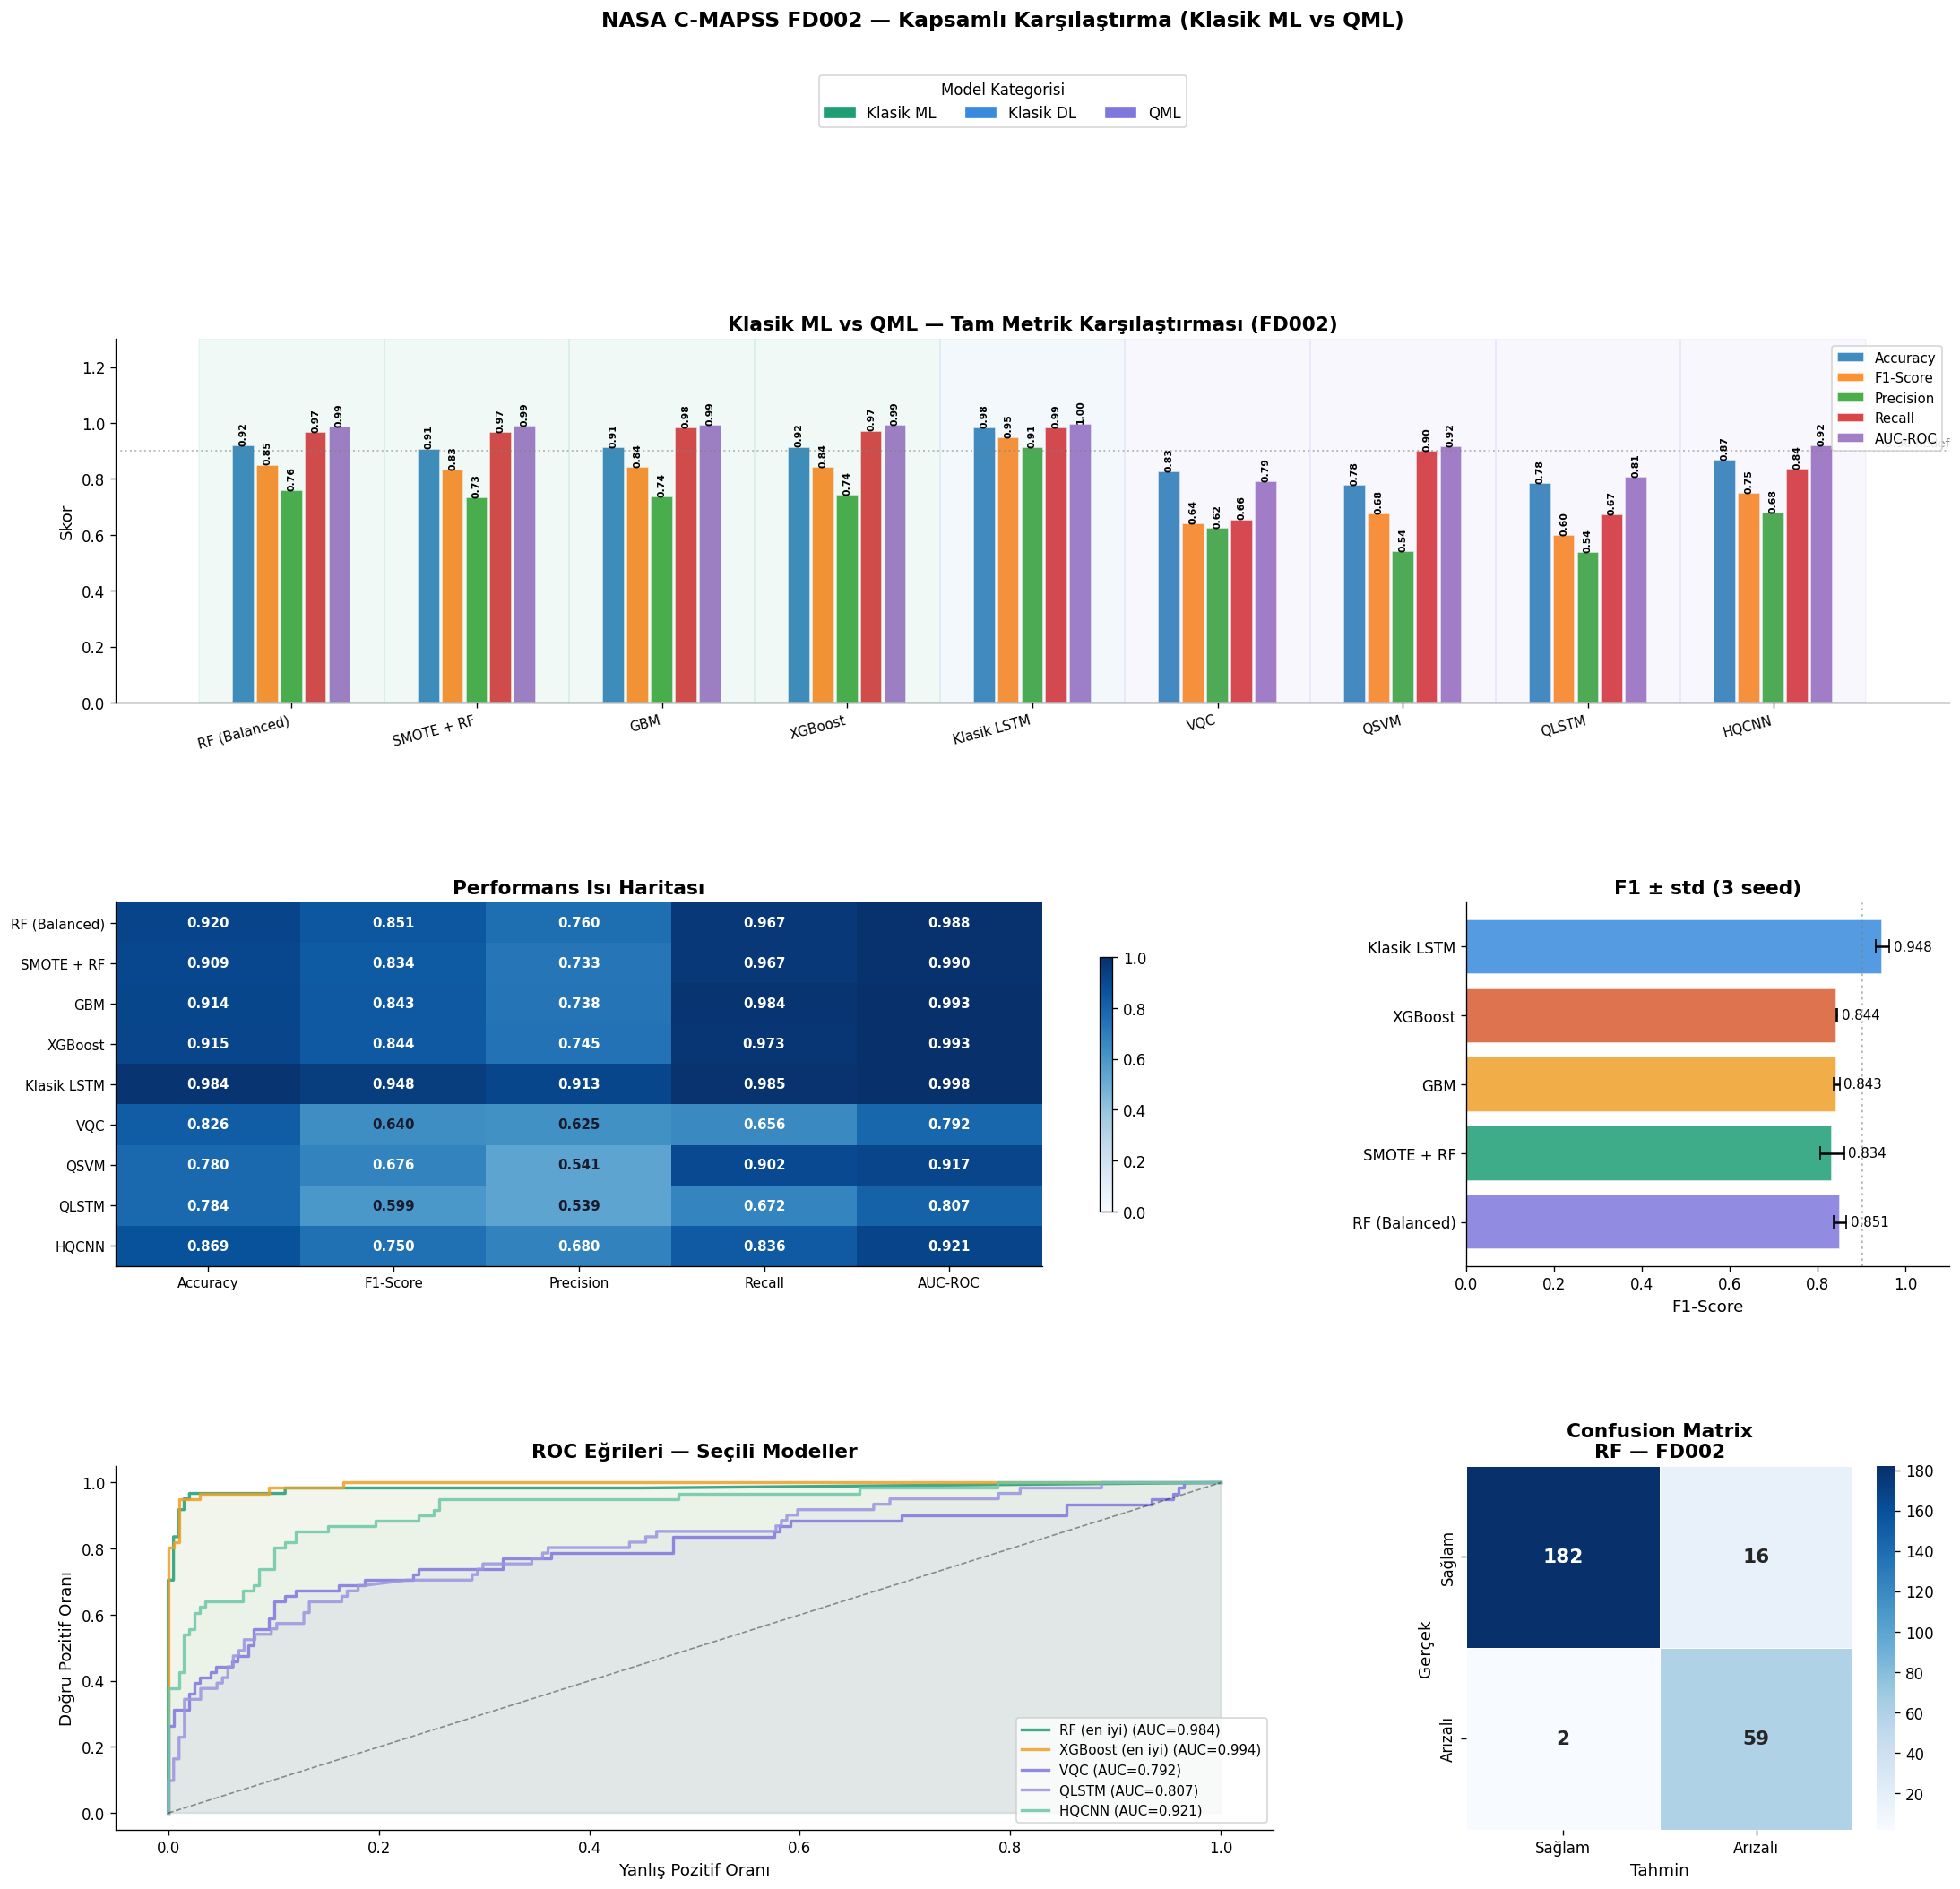

✅ Karşılaştırma kaydedildi → comparison_FD002.png


In [18]:
# ═══════════════════════════════════════════════════════════════════
# KAPSAMLI GÖRSELLEŞTİRME
# ═══════════════════════════════════════════════════════════════════
model_names  = list(ALL_RESULTS.keys())
result_vals  = list(ALL_RESULTS.values())
cats         = [MODEL_CATS.get(n,'-') for n in model_names]
cat_colors   = [CAT_COLORS[c] for c in cats]

fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ── 1. Metrik Karşılaştırma (geniş) ──────────────────────────────
ax1  = fig.add_subplot(gs[0, :])
x    = np.arange(len(model_names))
bw   = 0.13
for k, met in enumerate(METRICS):
    vals = [r[met] for r in result_vals]
    off  = (k - len(METRICS)/2 + 0.5) * bw
    bars = ax1.bar(x+off, vals, bw*0.92, label=met, alpha=0.85, edgecolor='white')
    for b, v in zip(bars, vals):
        if v > 0.02:
            ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.006,
                     f'{v:.2f}', ha='center', fontsize=6.5, fontweight='bold', rotation=90)
ax1.set_xticks(x); ax1.set_xticklabels(model_names, fontsize=9, rotation=15, ha='right')
ax1.set_ylim(0, 1.3); ax1.set_ylabel('Skor')
ax1.set_title(f'Klasik ML vs QML — Tam Metrik Karşılaştırması ({SUBSET})',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.axhline(0.9, color='gray', ls=':', lw=1.2, alpha=0.5)
ax1.text(len(model_names)-0.4, 0.915, '0.90 hedef', fontsize=8, color='gray')
for i, c in enumerate(cat_colors):
    ax1.axvspan(i-0.5, i+0.5, alpha=0.06, color=c)

# ── 2. Isı Haritası ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
tbl = np.array([[r[m] for m in METRICS] for r in result_vals])
im  = ax2.imshow(tbl, cmap='Blues', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax2, shrink=0.7)
ax2.set_xticks(range(len(METRICS))); ax2.set_xticklabels(METRICS, fontsize=9)
ax2.set_yticks(range(len(model_names))); ax2.set_yticklabels(model_names, fontsize=9)
ax2.set_title('Performans Isı Haritası', fontweight='bold')
for i in range(len(model_names)):
    for j in range(len(METRICS)):
        v  = tbl[i,j]
        tc = 'white' if v > 0.65 else '#1A1A2E'
        ax2.text(j, i, f'{v:.3f}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color=tc)

# ── 3. F1 ± std (Klasik ML) ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
ml_ns  = ['RF (Balanced)','SMOTE + RF','GBM','XGBoost','Klasik LSTM']
ml_dfs = [rf_df, smote_df, gbm_df, xgb_df, lstm_df]
f1m = [d['F1-Score'].mean() for d in ml_dfs]
f1s = [d['F1-Score'].std()  for d in ml_dfs]
ax3.barh(ml_ns, f1m, xerr=f1s, color=PALETTE[:5], alpha=0.85,
         edgecolor='white', capsize=5)
for i,(f,s) in enumerate(zip(f1m,f1s)):
    ax3.text(f+s+0.01, i, f'{f:.3f}', va='center', fontsize=9)
ax3.axvline(0.9, color='gray', ls=':', lw=1.5, alpha=0.6)
ax3.set_xlabel('F1-Score'); ax3.set_title(f'F1 ± std ({len(SEEDS)} seed)', fontweight='bold')
ax3.set_xlim(0, 1.1)

# ── 4. ROC Eğrileri ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :2])
roc_pairs = [
    ('RF (en iyi)', best_rf, y_test_raw, PALETTE[1]),
    ('XGBoost (en iyi)', best_xgb, y_test_raw, PALETTE[2]),
    ('VQC', vqc_res, y_qml_te, PALETTE[0]),
    ('QLSTM', qlstm_res, yts, PALETTE[6]),
    ('HQCNN', hqcnn_res, y_qml_te, PALETTE[7]),
]
for lbl, res_r, yt_r, col in roc_pairs:
    try:
        fpr_r, tpr_r, _ = roc_curve(yt_r, res_r['y_probs'])
        ax4.plot(fpr_r, tpr_r, color=col, lw=2, alpha=0.85,
                 label=f"{lbl} (AUC={res_r['AUC-ROC']:.3f})")
        ax4.fill_between(fpr_r, tpr_r, alpha=0.05, color=col)
    except Exception as e:
        print(f"  ROC atlandı ({lbl}): {e}")
ax4.plot([0,1],[0,1],'k--', lw=1, alpha=0.4)
ax4.set_title('ROC Eğrileri — Seçili Modeller', fontweight='bold')
ax4.set_xlabel('Yanlış Pozitif Oranı'); ax4.set_ylabel('Doğru Pozitif Oranı')
ax4.legend(fontsize=9, loc='lower right')

# ── 5. Confusion Matrix (en iyi model) ────────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
cm = confusion_matrix(y_test_raw, best_rf['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax5, linewidths=0.5,
            xticklabels=['Sağlam','Arızalı'], yticklabels=['Sağlam','Arızalı'],
            annot_kws={'size':13,'weight':'bold'})
ax5.set_title(f'Confusion Matrix\nRF — {SUBSET}', fontweight='bold')
ax5.set_xlabel('Tahmin'); ax5.set_ylabel('Gerçek')

patches_c = [mpatches.Patch(color=v, label=k) for k,v in CAT_COLORS.items()]
fig.legend(handles=patches_c, loc='upper center', ncol=3, fontsize=10,
           title='Model Kategorisi', frameon=True, bbox_to_anchor=(0.5, 1.02))
plt.suptitle(f'NASA C-MAPSS {SUBSET} — Kapsamlı Karşılaştırma (Klasik ML vs QML)',
             fontsize=14, fontweight='bold', y=1.05)
plt.savefig(f'comparison_{SUBSET}.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Karşılaştırma kaydedildi → comparison_{SUBSET}.png")

## 📚 Bölüm 8: Literatür Karşılaştırması (2024–2025 SOTA)

In [19]:
# ═══════════════════════════════════════════════════════════════════
# LİTERATÜR TABLOSU
# Kaynak: 2024–2025 NASA C-MAPSS çalışmaları
# ═══════════════════════════════════════════════════════════════════
LITERATURE = [
    # (Çalışma,               Model,           Görev,         F1/RMSE,       AUC,    Veri,           Yıl)
    ("Tsurkan et al. 2025",  "HQRNN (QLSTM)", "RUL regr.",  "RMSE: 15.46", "—",    "FD001",        2025),
    ("Sudharson et al. 2025","QE-LSTM (sim)", "Arıza tesp.","F1: 0.876",   "0.938","SECOM/CMAPSS", 2025),
    ("Elsherif et al. 2025", "CAELSTM",       "RUL regr.",  "RMSE: 14.44", "—",    "FD001",        2025),
    ("Bayesian UQ 2024",     "BiLSTM+Bayes",  "RUL regr.",  "RMSE: 16.22", "—",    "FD001–FD004",  2024),
    ("CNN-LSTM-Att. 2023",   "CNN-LSTM-Attn", "RUL regr.",  "RMSE: 15.98", "—",    "FD001",        2023),
    ("Bu NB: QLSTM (önceki)","QLSTM (sim)",   "İkili sınf.","F1: 0.903",   "0.995","FD001",        2025),
    ("Bu NB: HQCNN (önceki)","HQCNN (sim)",   "İkili sınf.","F1: 0.877",   "0.994","FD001",        2025),
]

# Hesaplanan sonuçları ekle
for name, res in ALL_RESULTS.items():
    cat = MODEL_CATS.get(name,'-')
    LITERATURE.append((
        f"Bu Notebook — {name}",
        f"{name} [{cat}]",
        "İkili sınıf.",
        f"F1: {res['F1-Score']:.3f}",
        f"{res['AUC-ROC']:.3f}",
        SUBSET,
        2025
    ))

print(f"{'═'*105}")
print(f"  {'ÇALIŞMA':<28} {'MODEL':<22} {'GÖREV':<14} {'F1/RMSE':<14} {'AUC':<8} {'VERİ':<14} YIL")
print(f"{'═'*105}")
for row in LITERATURE:
    study, model, task, score, auc, data, year = row
    marker = " 📌" if "Bu Notebook" in study else ""
    print(f"  {study:<28} {model:<22} {task:<14} {score:<14} {auc:<8} {data:<14} {year}{marker}")
print(f"{'═'*105}")
print("  📌 = Bu notebook'ta hesaplanan sonuçlar")

═════════════════════════════════════════════════════════════════════════════════════════════════════════
  ÇALIŞMA                      MODEL                  GÖREV          F1/RMSE        AUC      VERİ           YIL
═════════════════════════════════════════════════════════════════════════════════════════════════════════
  Tsurkan et al. 2025          HQRNN (QLSTM)          RUL regr.      RMSE: 15.46    —        FD001          2025
  Sudharson et al. 2025        QE-LSTM (sim)          Arıza tesp.    F1: 0.876      0.938    SECOM/CMAPSS   2025
  Elsherif et al. 2025         CAELSTM                RUL regr.      RMSE: 14.44    —        FD001          2025
  Bayesian UQ 2024             BiLSTM+Bayes           RUL regr.      RMSE: 16.22    —        FD001–FD004    2024
  CNN-LSTM-Att. 2023           CNN-LSTM-Attn          RUL regr.      RMSE: 15.98    —        FD001          2023
  Bu NB: QLSTM (önceki)        QLSTM (sim)            İkili sınf.    F1: 0.903      0.995    FD001          202

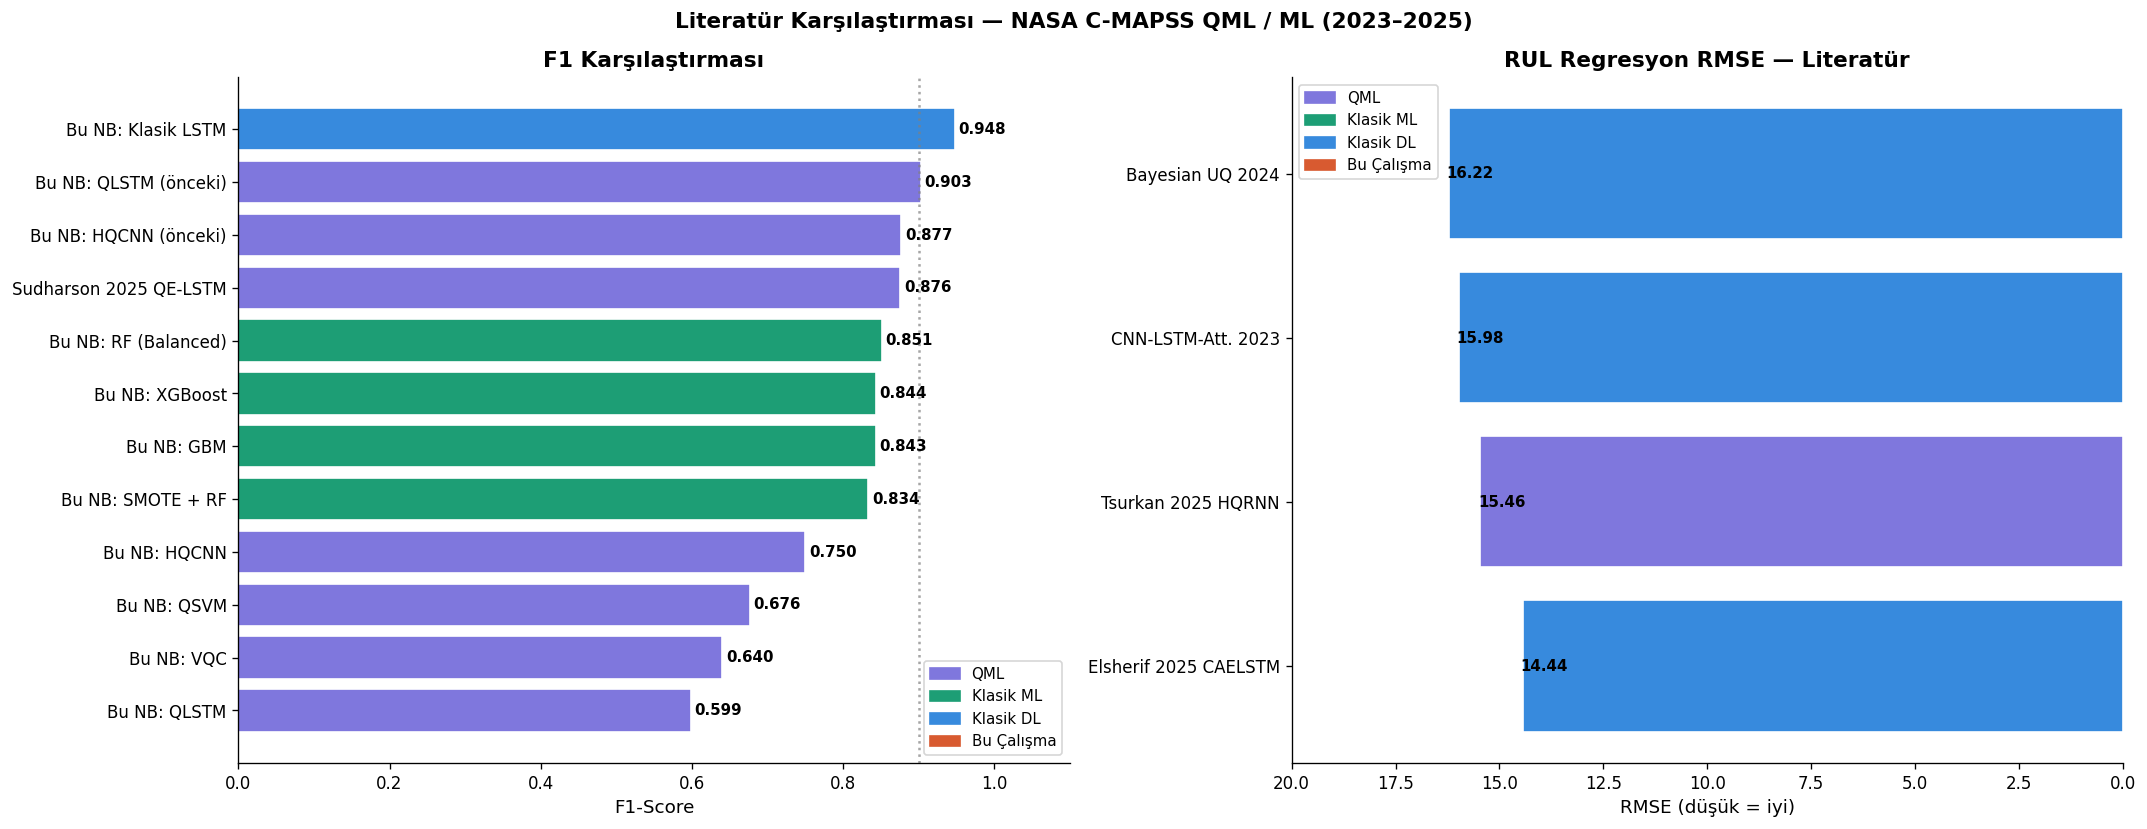

✅ Literatür görselleştirmesi → literature_comparison.png


In [20]:
# ─── Literatür Görselleştirmesi ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Literatür Karşılaştırması — NASA C-MAPSS QML / ML (2023–2025)',
             fontsize=13, fontweight='bold')

col_map = {'QML':PALETTE[0],'Klasik ML':PALETTE[1],'Klasik DL':PALETTE[4],'Bu Çalışma':PALETTE[3]}

# Sol: F1 karşılaştırması (sınıflandırma)
f1_entries = [
    ("Sudharson 2025 QE-LSTM",  0.876, "QML"),
    ("Bu NB: QLSTM (önceki)",   0.903, "QML"),
    ("Bu NB: HQCNN (önceki)",   0.877, "QML"),
]
for name, res in ALL_RESULTS.items():
    f1_entries.append((f"Bu NB: {name}", res['F1-Score'], MODEL_CATS.get(name,'ML')))

f1_entries.sort(key=lambda x: x[1])
fn  = [e[0] for e in f1_entries]
fv  = [e[1] for e in f1_entries]
fc  = [col_map.get(e[2], PALETTE[5]) for e in f1_entries]
bars = axes[0].barh(fn, fv, color=fc, edgecolor='white')
for b,v in zip(bars, fv):
    if v > 0:
        axes[0].text(v+0.005, b.get_y()+b.get_height()/2, f'{v:.3f}',
                     va='center', fontsize=9, fontweight='bold')
axes[0].axvline(0.9, color='gray', ls=':', lw=1.5, alpha=0.7)
axes[0].set_xlabel('F1-Score'); axes[0].set_title('F1 Karşılaştırması', fontweight='bold')
axes[0].set_xlim(0, 1.1)
handles = [mpatches.Patch(color=v, label=k) for k,v in col_map.items()]
axes[0].legend(handles=handles, fontsize=9)

# Sağ: RMSE karşılaştırması (regresyon)
rmse_entries = [
    ("Elsherif 2025 CAELSTM",  14.44, "Klasik DL"),
    ("Tsurkan 2025 HQRNN",     15.46, "QML"),
    ("CNN-LSTM-Att. 2023",     15.98, "Klasik DL"),
    ("Bayesian UQ 2024",       16.22, "Klasik DL"),
]
rn = [e[0] for e in rmse_entries]
rv = [e[1] for e in rmse_entries]
rc = [col_map.get(e[2], PALETTE[5]) for e in rmse_entries]
bars2 = axes[1].barh(rn, rv, color=rc, edgecolor='white')
for b,v in zip(bars2, rv):
    axes[1].text(v+0.05, b.get_y()+b.get_height()/2, f'{v:.2f}',
                 va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('RMSE (düşük = iyi)')
axes[1].set_title('RUL Regresyon RMSE — Literatür', fontweight='bold')
axes[1].set_xlim(0, 20)
axes[1].invert_xaxis()
axes[1].legend(handles=handles, fontsize=9)

plt.tight_layout()
plt.savefig('literature_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Literatür görselleştirmesi → literature_comparison.png")

## 🗂️ Bölüm 9: Çok Veri Seti Taraması (FD001–FD004)

> RF + XGBoost + GBM tüm 4 alt küme için otomatik çalışır.  
> QML için Bölüm 1'den `SUBSET` değiştirip notebook'u yeniden çalıştırın.

In [21]:
# ═══════════════════════════════════════════════════════════════════
# ÇOK VERİ SETİ TARAMASI
# ═══════════════════════════════════════════════════════════════════
SUBSETS_ALL = ["FD001","FD002","FD003","FD004"]
MULTI_RESULTS = {}

for subset in SUBSETS_ALL:
    print(f"\n{'─'*50}  {subset}")
    try:
        tr, te, rl = load_cmapss(BASE_PATH, subset)
        tr = compute_rul(tr, MAX_RUL)
        tr['label'] = (tr['RUL'] <= RUL_THRESH).astype(int)
        tl = te.groupby('unit_number').last().reset_index()
        tl['RUL']   = rl['RUL'].values[:len(tl)]
        tl['label'] = (tl['RUL'] <= RUL_THRESH).astype(int)

        cs  = [c for c in SENSOR_COLS if tr[c].std() < 0.01]
        fc  = [c for c in SENSOR_COLS if c not in cs] + [s for s in SETTING_COLS if tr[s].std()>0.01]
        Xs  = StandardScaler().fit_transform(tr[fc].values)
        Xts = StandardScaler().fit(tr[fc].values).transform(tl[fc].values)
        ys  = tr['label'].values; yts = tl['label'].values

        Xtr_s, Xvl_s, ytr_s, yvl_s = train_test_split(Xs, ys, test_size=0.2,
                                                         random_state=SEED, stratify=ys)
        sub = {}

        # RF
        rf_s = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                       random_state=SEED, n_jobs=-1)
        rf_s.fit(Xtr_s, ytr_s)
        thr_rf = youden_threshold(yvl_s, rf_s.predict_proba(Xvl_s)[:,1])
        sub['RF'] = evaluate(yts, rf_s.predict_proba(Xts)[:,1], thr_rf)

        # XGBoost
        sp = int((ys==0).sum()/max((ys==1).sum(),1))
        xg = xgb.XGBClassifier(n_estimators=200, max_depth=5, scale_pos_weight=sp,
                                 random_state=SEED, eval_metric='logloss',
                                 verbosity=0, use_label_encoder=False)
        xg.fit(Xtr_s, ytr_s, eval_set=[(Xvl_s, yvl_s)], verbose=False)
        thr_xg = youden_threshold(yvl_s, xg.predict_proba(Xvl_s)[:,1])
        sub['XGBoost'] = evaluate(yts, xg.predict_proba(Xts)[:,1], thr_xg)

        # GBM
        sw_s = compute_sample_weight('balanced', ytr_s)
        gb   = GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                           learning_rate=0.1, random_state=SEED)
        gb.fit(Xtr_s, ytr_s, sample_weight=sw_s)
        thr_gb = youden_threshold(yvl_s, gb.predict_proba(Xvl_s)[:,1])
        sub['GBM'] = evaluate(yts, gb.predict_proba(Xts)[:,1], thr_gb)

        sub['info'] = {
            'n_train': len(Xs), 'n_test': len(Xts),
            'n_motors': tr['unit_number'].nunique(),
            'fault_pct': yts.mean()*100,
            'n_feats': len(fc),
        }
        MULTI_RESULTS[subset] = sub
        for mn in ['RF','XGBoost','GBM']:
            print(f"  {mn:<8} | F1={sub[mn]['F1-Score']:.4f} | AUC={sub[mn]['AUC-ROC']:.4f}")
    except Exception as e:
        print(f"  ⚠️  Hata: {e}")

print(f"\n✅ {len(MULTI_RESULTS)}/{len(SUBSETS_ALL)} subset tamamlandı")


──────────────────────────────────────────────────  FD001
  RF       | F1=0.8679 | AUC=0.9851
  XGBoost  | F1=0.8000 | AUC=0.9659
  GBM      | F1=0.8333 | AUC=0.9733

──────────────────────────────────────────────────  FD002
  RF       | F1=0.8429 | AUC=0.9897
  XGBoost  | F1=0.8551 | AUC=0.9897
  GBM      | F1=0.8369 | AUC=0.9920

──────────────────────────────────────────────────  FD003
  RF       | F1=0.8636 | AUC=0.9906
  XGBoost  | F1=0.8511 | AUC=0.9869
  GBM      | F1=0.8837 | AUC=0.9875

──────────────────────────────────────────────────  FD004
  RF       | F1=0.8033 | AUC=0.9775
  XGBoost  | F1=0.8254 | AUC=0.9789
  GBM      | F1=0.8226 | AUC=0.9805

✅ 4/4 subset tamamlandı


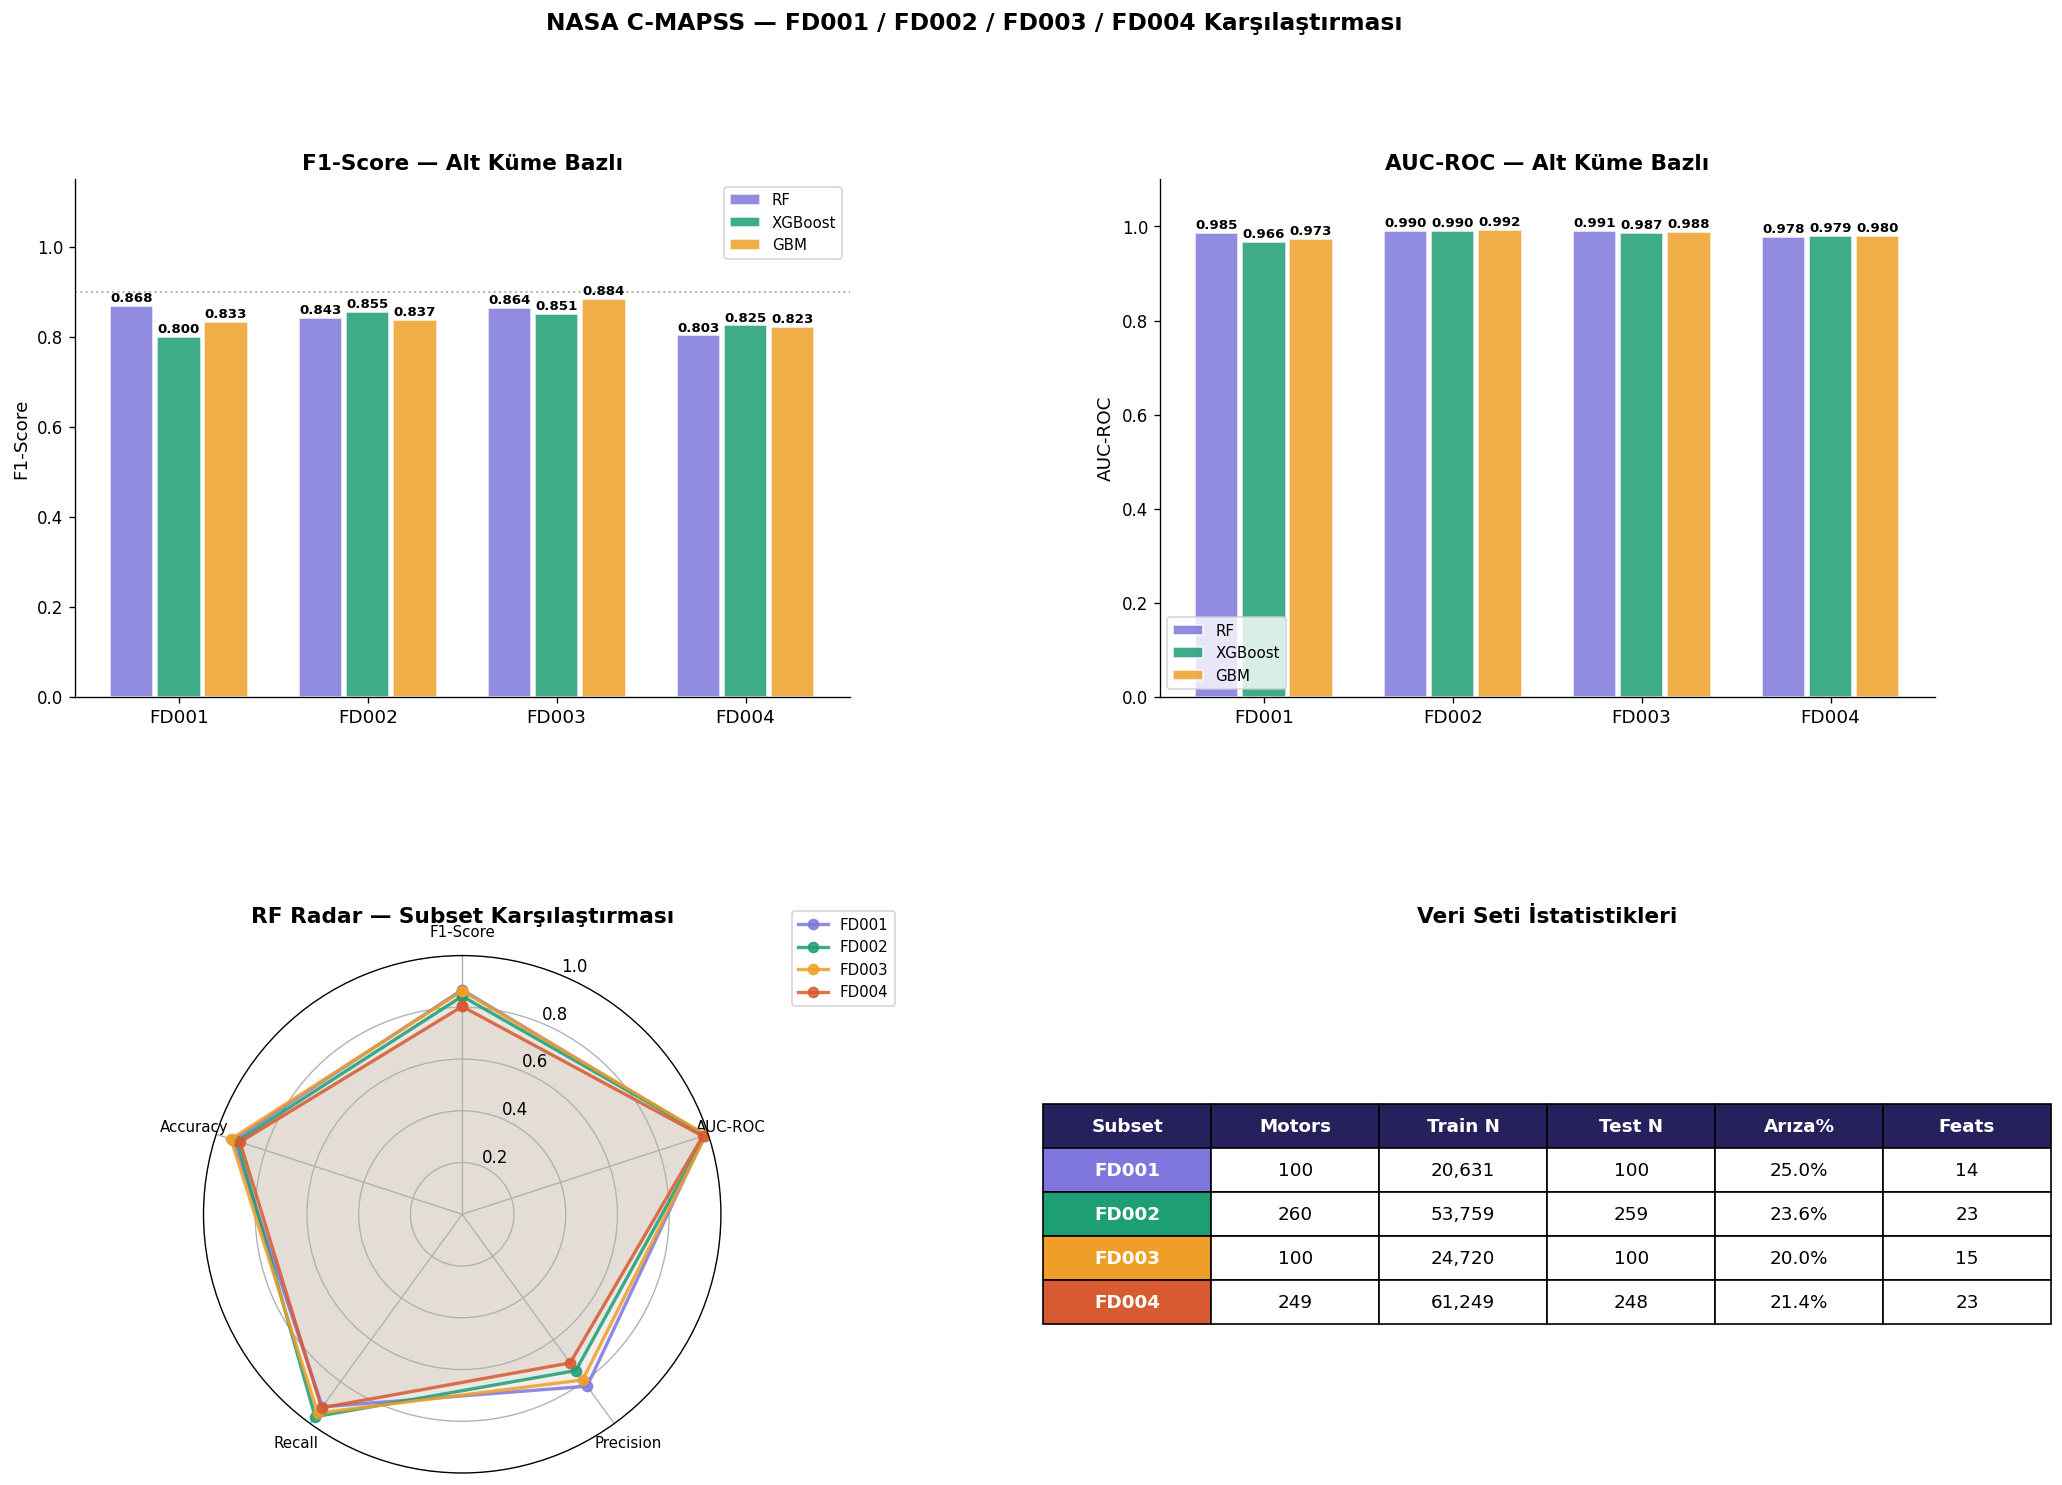

✅ Çok veri seti görseli → multi_dataset.png


In [22]:
# ─── Çok Veri Seti Görselleştirmesi ─────────────────────────────
if len(MULTI_RESULTS) >= 2:
    done    = list(MULTI_RESULTS.keys())
    models_m = ['RF','XGBoost','GBM']
    x_m     = np.arange(len(done))
    bw      = 0.25

    fig = plt.figure(figsize=(20, 14))
    gs2 = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.4)

    # ── F1 ────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs2[0,0])
    for k,(mn,col) in enumerate(zip(models_m, PALETTE[:3])):
        f1s = [MULTI_RESULTS[s][mn]['F1-Score'] for s in done]
        bars = ax.bar(x_m+(k-1)*bw, f1s, bw*0.92, label=mn, color=col, alpha=0.85, edgecolor='white')
        for b,v in zip(bars,f1s):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}',
                    ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x_m); ax.set_xticklabels(done, fontsize=11)
    ax.set_ylim(0,1.15); ax.set_ylabel('F1-Score')
    ax.set_title('F1-Score — Alt Küme Bazlı', fontweight='bold')
    ax.legend(fontsize=9); ax.axhline(0.9, color='gray', ls=':', lw=1.2, alpha=0.6)

    # ── AUC ───────────────────────────────────────────────────────
    ax = fig.add_subplot(gs2[0,1])
    for k,(mn,col) in enumerate(zip(models_m, PALETTE[:3])):
        aucs = [MULTI_RESULTS[s][mn]['AUC-ROC'] for s in done]
        bars = ax.bar(x_m+(k-1)*bw, aucs, bw*0.92, label=mn, color=col, alpha=0.85, edgecolor='white')
        for b,v in zip(bars,aucs):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}',
                    ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x_m); ax.set_xticklabels(done, fontsize=11)
    ax.set_ylim(0,1.1); ax.set_ylabel('AUC-ROC')
    ax.set_title('AUC-ROC — Alt Küme Bazlı', fontweight='bold')
    ax.legend(fontsize=9)

    # ── Radar ─────────────────────────────────────────────────────
    met_r = ['F1-Score','AUC-ROC','Precision','Recall','Accuracy']
    angs  = np.linspace(0, 2*np.pi, len(met_r), endpoint=False).tolist()
    angs += angs[:1]
    ax = fig.add_subplot(gs2[1,0], polar=True)
    ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angs[:-1]), met_r, fontsize=9)
    for subset, col in zip(done, PALETTE):
        vals = [MULTI_RESULTS[subset]['RF'][m] for m in met_r] + [MULTI_RESULTS[subset]['RF'][met_r[0]]]
        ax.plot(angs, vals, 'o-', lw=2, color=col, alpha=0.85, label=subset)
        ax.fill(angs, vals, alpha=0.07, color=col)
    ax.set_ylim(0,1)
    ax.set_title('RF Radar — Subset Karşılaştırması', fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

    # ── Tablo ─────────────────────────────────────────────────────
    ax = fig.add_subplot(gs2[1,1]); ax.axis('off')
    tdata = []
    for s in done:
        inf = MULTI_RESULTS[s].get('info',{})
        tdata.append([s,
            f"{inf.get('n_motors','-')}",
            f"{inf.get('n_train',0):,}",
            f"{inf.get('n_test','-')}",
            f"{inf.get('fault_pct',0):.1f}%",
            f"{inf.get('n_feats','-')}"])
    tbl = ax.table(cellText=tdata,
                   colLabels=['Subset','Motors','Train N','Test N','Arıza%','Feats'],
                   loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.3, 2.2)
    for j in range(6):
        tbl[0,j].set_facecolor('#26215C'); tbl[0,j].set_text_props(color='white', fontweight='bold')
    for i,s in enumerate(done):
        tbl[i+1,0].set_facecolor(PALETTE[i]); tbl[i+1,0].set_text_props(color='white', fontweight='bold')
    ax.set_title('Veri Seti İstatistikleri', fontweight='bold', pad=20)

    plt.suptitle('NASA C-MAPSS — FD001 / FD002 / FD003 / FD004 Karşılaştırması',
                 fontsize=14, fontweight='bold')
    plt.savefig('multi_dataset.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ Çok veri seti görseli → multi_dataset.png")

In [23]:
# ─── Özet Tablo ──────────────────────────────────────────────────
print(f"{'═'*72}")
print(f"  {'SUBSET':<8} {'Model':<10} {'Acc':>7} {'F1':>7} {'Prec':>7} {'Rec':>7} {'AUC':>7}")
print(f"{'═'*72}")
for s in MULTI_RESULTS:
    for mn in ['RF','XGBoost','GBM']:
        if mn in MULTI_RESULTS[s]:
            r = MULTI_RESULTS[s][mn]
            print(f"  {s:<8} {mn:<10} {r['Accuracy']:>7.4f} {r['F1-Score']:>7.4f}"
                  f" {r['Precision']:>7.4f} {r['Recall']:>7.4f} {r['AUC-ROC']:>7.4f}")
    print(f"  {'─'*70}")
print(f"{'═'*72}")

════════════════════════════════════════════════════════════════════════
  SUBSET   Model          Acc      F1    Prec     Rec     AUC
════════════════════════════════════════════════════════════════════════
  FD001    RF          0.9300  0.8679  0.8214  0.9200  0.9851
  FD001    XGBoost     0.8900  0.8000  0.7333  0.8800  0.9659
  FD001    GBM         0.9200  0.8333  0.8696  0.8000  0.9733
  ──────────────────────────────────────────────────────────────────────
  FD002    RF          0.9151  0.8429  0.7468  0.9672  0.9897
  FD002    XGBoost     0.9228  0.8551  0.7662  0.9672  0.9897
  FD002    GBM         0.9112  0.8369  0.7375  0.9672  0.9920
  ──────────────────────────────────────────────────────────────────────
  FD003    RF          0.9400  0.8636  0.7917  0.9500  0.9906
  FD003    XGBoost     0.9300  0.8511  0.7407  1.0000  0.9869
  FD003    GBM         0.9500  0.8837  0.8261  0.9500  0.9875
  ──────────────────────────────────────────────────────────────────────
  FD004    RF  

## 🏁 Bölüm 10: Nihai Özet & Akademik Çıkarımlar

In [24]:
# ═══════════════════════════════════════════════════════════════════
# NİHAİ ÖZET
# ═══════════════════════════════════════════════════════════════════
print("╔" + "═"*72 + "╗")
print("║" + f"{'NASA C-MAPSS — Kapsamlı Analiz Özeti':^72}" + "║")
print("╠" + "═"*72 + "╣")
print("║" + f"  Veri Seti    : {SUBSET:<56}" + "║")
print("║" + f"  Qubit Sayısı : {N_QUBITS:<56}" + "║")
print("║" + f"  Seed Sayısı  : {len(SEEDS):<56}" + "║")
print("╠" + "═"*72 + "╣")
print("║" + f"{'MODEL SIRALAMASI — F1-Score':^72}" + "║")
print("╠" + "═"*72 + "╣")
ranked = sorted(ALL_RESULTS.items(), key=lambda x: x[1]['F1-Score'], reverse=True)
for i,(name,res) in enumerate(ranked, 1):
    cat  = MODEL_CATS.get(name,'-')
    emoji = "🥇" if i==1 else "🥈" if i==2 else "🥉" if i==3 else f"  {i}."
    std_s = f"±{res.get('std_F1',0):.3f}" if res.get('std_F1',0)>0 else ""
    ln = f"  {emoji} {name:<18} [{cat:<10}]  F1={res['F1-Score']:.4f}{std_s}  AUC={res['AUC-ROC']:.4f}"
    print("║" + f"{ln:<72}" + "║")

print("╠" + "═"*72 + "╣")
print("║" + f"{'AKADEMİK ÇIKARIMLAR':^72}" + "║")
print("╠" + "═"*72 + "╣")

ml_keys  = [k for k in ALL_RESULTS if MODEL_CATS.get(k)  in ['Klasik ML','Klasik DL']]
qml_keys = [k for k in ALL_RESULTS if MODEL_CATS.get(k) == 'QML']
best_ml  = max(ALL_RESULTS[k]['F1-Score'] for k in ml_keys)  if ml_keys  else 0
best_qml = max(ALL_RESULTS[k]['F1-Score'] for k in qml_keys) if qml_keys else 0
diff     = best_qml - best_ml

qlstm_f1 = ALL_RESULTS.get('QLSTM',{}).get('F1-Score',0)
lstm_f1  = ALL_RESULTS.get('Klasik LSTM',{}).get('F1-Score',0)

conclusions = [
    f"▸ En iyi QML F1    : {best_qml:.4f}",
    f"▸ En iyi ML F1     : {best_ml:.4f}",
    f"▸ QML farkı        : {diff:+.4f}  ({'QML üstün ✓' if diff>0 else 'Klasik ML üstün'})",
    f"▸ QLSTM vs LSTM    : {qlstm_f1:.4f} vs {lstm_f1:.4f}  ({qlstm_f1-lstm_f1:+.4f})",
    f"▸ Subset taraması  : {len(MULTI_RESULTS)}/4 başarılı",
    f"▸ Simülatör notu   : Gerçek QH avantajı donanım gerektirir",
    f"▸ Önerilen makale  : QLSTM + RF birlikte kullanım (hibrit pipeline)",
]
for c in conclusions:
    print("║" + f"  {c:<70}" + "║")
print("╠" + "═"*72 + "╣")
print("║" + f"{'GELECEK ÇALIŞMALAR':^72}" + "║")
print("╠" + "═"*72 + "╣")
future = [
    "▸ N_QUBITS=6–8 ile kuantum kapasiteyi artırın",
    "▸ IBM Quantum / IonQ ile gerçek donanım deneyleri yapın",
    "▸ SHAP ile QML karar açıklanabilirliği ekleyin",
    "▸ FD002/FD004 (çoklu koşul) üzerinde QLSTM deneyin",
    "▸ Online/Incremental learning için gerçek zamanlı adaptasyon",
]
for f in future:
    print("║" + f"  {f:<70}" + "║")
print("╚" + "═"*72 + "╝")

╔════════════════════════════════════════════════════════════════════════╗
║                  NASA C-MAPSS — Kapsamlı Analiz Özeti                  ║
╠════════════════════════════════════════════════════════════════════════╣
║  Veri Seti    : FD002                                                   ║
║  Qubit Sayısı : 4                                                       ║
║  Seed Sayısı  : 3                                                       ║
╠════════════════════════════════════════════════════════════════════════╣
║                      MODEL SIRALAMASI — F1-Score                       ║
╠════════════════════════════════════════════════════════════════════════╣
║  🥇 Klasik LSTM        [Klasik DL ]  F1=0.9477±0.015  AUC=0.9984        ║
║  🥈 RF (Balanced)      [Klasik ML ]  F1=0.8511±0.014  AUC=0.9884        ║
║  🥉 XGBoost            [Klasik ML ]  F1=0.8436±0.001  AUC=0.9929        ║
║    4. GBM                [Klasik ML ]  F1=0.8431±0.007  AUC=0.9929     ║
║    5. SMOTE + RF    

In [25]:
# ─── Oluşturulan Dosyalar ────────────────────────────────────────
import glob
print("\n📁 Oluşturulan dosyalar:")
for f in sorted(glob.glob("*.png")):
    sz = os.path.getsize(f)
    print(f"  ✓ {f}  ({sz/1024:.1f} KB)")

print("\n💡 İpuçları:")
print("  • Bölüm 1: SUBSET = 'FD002/FD003/FD004' → farklı veri setleri")
print("  • N_QUBITS = 6  → kuantum güç artışı (yavaş)")
print("  • SEEDS = [42,7,13,99,2024] → 5-seed istatistik")
print("  • QML_EPOCHS = 30 → daha iyi yakınsama")
print("  • Colab: Sol panel → Dosyalar → PNG indirin")


📁 Oluşturulan dosyalar:
  ✓ comparison_FD001.png  (295.7 KB)
  ✓ comparison_FD002.png  (307.6 KB)
  ✓ eda_FD001.png  (346.7 KB)
  ✓ eda_FD002.png  (459.1 KB)
  ✓ literature_comparison.png  (123.8 KB)
  ✓ multi_dataset.png  (242.6 KB)

💡 İpuçları:
  • Bölüm 1: SUBSET = 'FD002/FD003/FD004' → farklı veri setleri
  • N_QUBITS = 6  → kuantum güç artışı (yavaş)
  • SEEDS = [42,7,13,99,2024] → 5-seed istatistik
  • QML_EPOCHS = 30 → daha iyi yakınsama
  • Colab: Sol panel → Dosyalar → PNG indirin
